# 🎻 Violin Expressiveness → Emotion Recognition — Full Pipeline
**PhD Thesis · Expressive Techniques in Violin Performance & Their Emotional Effect on the Audience**

### Research question
> Do large-model SSL embeddings outperform hand-crafted low-level acoustic features for predicting perceived emotion from expressive solo violin? Does combining both outperform either alone?

### Pipeline at a glance
```
Questionnaire CSVs (Greek, wide-format)
  → parse → aggregate → VA-derived multi-label ground truth
  → MEC excerpts → Neutral by rule (excluded from classifier)

60 audio files (20 pieces × MEC / EXP / EXG)
  ├─ MERT-v1-95M     (frozen, layers 5-7)  → 768-dim  ─┐  Set A
  ├─ Essentia MusiCNN (DNN)                  → 200-dim  ─┘  SSL Embeddings
  │
  ├─ CREPE            (pitch/vibrato)         →   8-dim  ─┐  Set B
  ├─ madmom           (timing/IOI)            →   8-dim   │  Low-Level
  ├─ Essentia DSP     (dynamics/timbre)       →  20-dim   │  Acoustic
  └─ DTW              (warp path stats)       →   6-dim  ─┘

Set C = A + B  (combined)

8 classifiers × 3 feature sets × LOOCV → multi-label metrics
+ VA regression (Ridge/SVR/MLP) + baseline (MFCC+SVM)
+ Analysis A–D
```

## 0. Installation

In [1]:
# §1 — Installation
# P100 = compute capability sm_60 (Pascal). PyTorch ≥ 2.4 dropped sm_60 support.
# Must pin to 2.3.1 FIRST — before other installs can accidentally pull a newer torch.

import subprocess, sys

def pip_install(packages, label):
    r = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q'] + packages,
        capture_output=True, text=True
    )
    ok = r.returncode == 0
    print(f'{"✅" if ok else "❌"} {label}')
    if not ok:
        print(f'   ↳ {r.stderr.strip()[-400:]}')
    return ok

# ── PyTorch 2.3.1 — last release supporting P100 (sm_60) ─────────────────────
pip_install([
    'torch==2.3.1',
    'torchvision==0.18.1',
    'torchaudio==2.3.1',
    '--index-url', 'https://download.pytorch.org/whl/cu121'
], 'PyTorch 2.3.1 (sm_60 / P100 compatible)')

# ── Everything else ───────────────────────────────────────────────────────────
pip_install(['librosa', 'soundfile'],                          'librosa + soundfile')
pip_install(['statsmodels', 'xgboost'],                        'statsmodels + xgboost')
pip_install(['transformers>=4.38,<4.42', 'accelerate'],        'transformers')
pip_install(['crepe', 'resampy'],                              'crepe (pitch tracker)')
pip_install(['shap'],                                              'shap (feature importance)')

print('\n✅ Installation complete — restart kernel, then run all cells top-to-bottom')

✅ PyTorch 2.3.1 (sm_60 / P100 compatible)
✅ librosa + soundfile
✅ statsmodels + xgboost
✅ transformers
✅ crepe (pitch tracker)
✅ shap (feature importance)

✅ Installation complete — restart kernel, then run all cells top-to-bottom


## 1. Imports & GPU Check

In [2]:
import os, re, ast, warnings, urllib.request
import numpy as np
import pandas as pd
import torch
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from collections import Counter
from scipy.stats import pearsonr, wilcoxon, spearmanr
import shap
from scipy.signal import butter, filtfilt, welch
from sklearn.svm import SVC, SVR
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import (
    hamming_loss, f1_score, accuracy_score,
    mean_squared_error, confusion_matrix
)
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from transformers import AutoModel, AutoProcessor
warnings.filterwarnings('ignore')

# ── Required packages (hard imports — no fallbacks) ──────────────────────────
import crepe
print('✅ crepe')


DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'\n{"✅" if DEVICE=="cuda" else "⚠️"}  Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'   GPU : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

✅ crepe

✅  Device: cuda
   GPU : Tesla P100-PCIE-16GB
   VRAM: 17.1 GB


## 2. Configuration
**Edit this cell before running anything else.**

In [3]:
# ─── PATHS ────────────────────────────────────────────────────────────────────
AUDIO_DIR    = '/kaggle/input/datasets/george031218732003/violin-thesis-data/ThesisDataset'
OUTPUT_DIR   = '/kaggle/working/pipeline_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─── QUESTIONNAIRE CSV FILES ──────────────────────────────────────────────────
# Upload your form CSVs as a separate Kaggle dataset (e.g. violin-thesis-forms)
# They will be mounted at /kaggle/input/violin-thesis-forms/
QUESTIONNAIRE_CSV_PATHS = [
    '/kaggle/input/datasets/george031218732003/violin-thesis-forms/Forms/questionnaire_1.csv',
    '/kaggle/input/datasets/george031218732003/violin-thesis-forms/Forms/questionnaire_2.csv',
    '/kaggle/input/datasets/george031218732003/violin-thesis-forms/Forms/questionnaire_3.csv',
    '/kaggle/input/datasets/george031218732003/violin-thesis-forms/Forms/questionnaire_4.csv',
    '/kaggle/input/datasets/george031218732003/violin-thesis-forms/Forms/questionnaire_5.csv',
]

# ─── EXCERPT ORDER PER QUESTIONNAIRE ─────────────────────────────────────────
QUESTIONNAIRE_EXCERPT_MAP = {
    '/kaggle/input/datasets/george031218732003/violin-thesis-forms/Forms/questionnaire_1.csv': [
        'Bach_Adagio_S1_MEC',           # Απόσπασμα 1
        'Bruch_VC1_EXG',                # Απόσπασμα 2
        'Cinema_Paradiso_EXP',          # Απόσπασμα 3
        'Don_Juan_EXG',                 # Απόσπασμα 4
        'Godfather_MEC',                # Απόσπασμα 5
        'La_Vita_E_Bella_MEC',          # Απόσπασμα 6
        'Meditation_Thais_EXP',         # Απόσπασμα 7
        'Mendelssohn_VC_Mvt2_MEC',      # Απόσπασμα 8
        'Mozart_VC3_EXG',               # Απόσπασμα 9
        'Mozart_VC4_MEC',               # Απόσπασμα 10
        'Schindlers_List_MEC',          # Απόσπασμα 11
        'Secret_Garden_EXP',            # Απόσπασμα 12
        'Shostakovich_SQ8_exrpt1_EXP',  # Απόσπασμα 13
        'Shostakovich_SQ8_exrpt2_MEC',  # Απόσπασμα 14
        'Shostakovich_SQ8_exrpt3_EXG',  # Απόσπασμα 15
        'Shostakovich_Sym5_Mvt1_MEC',   # Απόσπασμα 16
        'Shostakovich_Sym5_Mvt3_EXP',   # Απόσπασμα 17
        'Shostakovich_VC1_EXP',         # Απόσπασμα 18
        'Tanzil_Serenade_EXP',          # Απόσπασμα 19
        'Vitali_Chaconne_EXP',          # Απόσπασμα 20
    ],
     '/kaggle/input/datasets/george031218732003/violin-thesis-forms/Forms/questionnaire_2.csv': [
        'Bach_Adagio_S1_EXG',           # Απόσπασμα 1
        'Bruch_VC1_EXP',                # Απόσπασμα 2
        'Cinema_Paradiso_EXP',          # Απόσπασμα 3
        'Don_Juan_EXP',                 # Απόσπασμα 4
        'Godfather_EXG',                # Απόσπασμα 5
        'La_Vita_E_Bella_EXG',          # Απόσπασμα 6
        'Meditation_Thais_MEC',         # Απόσπασμα 7
        'Mendelssohn_VC_Mvt2_EXG',      # Απόσπασμα 8
        'Mozart_VC3_EXP',               # Απόσπασμα 9
        'Mozart_VC4_MEC',               # Απόσπασμα 10
        'Schindlers_List_MEC',          # Απόσπασμα 11
        'Secret_Garden_EXP',            # Απόσπασμα 12
        'Shostakovich_SQ8_exrpt1_EXP',  # Απόσπασμα 13
        'Shostakovich_SQ8_exrpt2_MEC',  # Απόσπασμα 14
        'Shostakovich_SQ8_exrpt3_EXP',  # Απόσπασμα 15
        'Shostakovich_Sym5_Mvt1_MEC',   # Απόσπασμα 16
        'Shostakovich_Sym5_Mvt3_MEC',   # Απόσπασμα 17
        'Shostakovich_VC1_MEC',         # Απόσπασμα 18
        'Tanzil_Serenade_EXP',          # Απόσπασμα 19
        'Vitali_Chaconne_MEC',          # Απόσπασμα 20
    ],
    '/kaggle/input/datasets/george031218732003/violin-thesis-forms/Forms/questionnaire_3.csv': [
        'Bach_Adagio_S1_EXP',           # Απόσπασμα 1
        'Bruch_VC1_EXP',                # Απόσπασμα 2
        'Cinema_Paradiso_MEC',          # Απόσπασμα 3
        'Don_Juan_EXP',                 # Απόσπασμα 4
        'Godfather_EXP',                # Απόσπασμα 5
        'La_Vita_E_Bella_EXP',          # Απόσπασμα 6
        'Meditation_Thais_MEC',         # Απόσπασμα 7
        'Mendelssohn_VC_Mvt2_EXP',      # Απόσπασμα 8
        'Mozart_VC3_EXP',               # Απόσπασμα 9
        'Mozart_VC4_EXG',               # Απόσπασμα 10
        'Schindlers_List_EXG',          # Απόσπασμα 11
        'Secret_Garden_MEC',            # Απόσπασμα 12
        'Shostakovich_SQ8_exrpt1_MEC',  # Απόσπασμα 13
        'Shostakovich_SQ8_exrpt2_EXG',  # Απόσπασμα 14
        'Shostakovich_SQ8_exrpt3_EXP',  # Απόσπασμα 15
        'Shostakovich_Sym5_Mvt1_EXG',   # Απόσπασμα 16
        'Shostakovich_Sym5_Mvt3_MEC',   # Απόσπασμα 17
        'Shostakovich_VC1_MEC',         # Απόσπασμα 18
        'Tanzil_Serenade_MEC',          # Απόσπασμα 19
        'Vitali_Chaconne_MEC',          # Απόσπασμα 20
    ],
    '/kaggle/input/datasets/george031218732003/violin-thesis-forms/Forms/questionnaire_4.csv': [
        'Bach_Adagio_S1_EXP',           # Απόσπασμα 1
        'Bruch_VC1_MEC',                # Απόσπασμα 2
        'Cinema_Paradiso_MEC',          # Απόσπασμα 3
        'Don_Juan_MEC',                 # Απόσπασμα 4
        'Godfather_EXP',                # Απόσπασμα 5
        'La_Vita_E_Bella_EXP',          # Απόσπασμα 6
        'Meditation_Thais_EXG',         # Απόσπασμα 7
        'Mendelssohn_VC_Mvt2_EXP',      # Απόσπασμα 8
        'Mozart_VC3_MEC',               # Απόσπασμα 9
        'Mozart_VC4_EXP',               # Απόσπασμα 10
        'Schindlers_List_EXP',          # Απόσπασμα 11
        'Secret_Garden_MEC',            # Απόσπασμα 12
        'Shostakovich_SQ8_exrpt1_MEC',  # Απόσπασμα 13
        'Shostakovich_SQ8_exrpt2_EXP',  # Απόσπασμα 14
        'Shostakovich_SQ8_exrpt3_MEC',  # Απόσπασμα 15
        'Shostakovich_Sym5_Mvt1_EXP',   # Απόσπασμα 16
        'Shostakovich_Sym5_Mvt3_EXG',   # Απόσπασμα 17
        'Shostakovich_VC1_EXG',         # Απόσπασμα 18
        'Tanzil_Serenade_MEC',          # Απόσπασμα 19
        'Vitali_Chaconne_EXG',          # Απόσπασμα 20
    ],
    '/kaggle/input/datasets/george031218732003/violin-thesis-forms/Forms/questionnaire_5.csv': [
        'Bach_Adagio_S1_MEC',           # Απόσπασμα 1
        'Bruch_VC1_MEC',                # Απόσπασμα 2
        'Cinema_Paradiso_EXG',          # Απόσπασμα 3
        'Don_Juan_MEC',                 # Απόσπασμα 4
        'Godfather_MEC',                # Απόσπασμα 5
        'La_Vita_E_Bella_MEC',          # Απόσπασμα 6
        'Meditation_Thais_EXP',         # Απόσπασμα 7
        'Mendelssohn_VC_Mvt2_MEC',      # Απόσπασμα 8
        'Mozart_VC3_MEC',               # Απόσπασμα 9
        'Mozart_VC4_EXP',               # Απόσπασμα 10
        'Schindlers_List_EXP',          # Απόσπασμα 11
        'Secret_Garden_EXG',            # Απόσπασμα 12
        'Shostakovich_SQ8_exrpt1_EXG',  # Απόσπασμα 13
        'Shostakovich_SQ8_exrpt2_EXP',  # Απόσπασμα 14
        'Shostakovich_SQ8_exrpt3_MEC',  # Απόσπασμα 15
        'Shostakovich_Sym5_Mvt1_EXP',   # Απόσπασμα 16
        'Shostakovich_Sym5_Mvt3_EXP',   # Απόσπασμα 17
        'Shostakovich_VC1_EXP',         # Απόσπασμα 18
        'Tanzil_Serenade_EXG',          # Απόσπασμα 19
        'Vitali_Chaconne_EXP',          # Απόσπασμα 20
    ],
}

# ─── CONSTANTS ────────────────────────────────────────────────────────────────
EMOTION_LABELS = [
    'Tenderness','Nostalgia','Peacefulness','Power',
    'Joyful Activation','Tension','Sadness','Neutral'
]
CONDITIONS = {'MEC':'Mechanical','EXP':'Expressive','EXG':'Exaggerated'}
SAMPLE_RATE   = 24000
MERT_LAYERS   = [5, 6, 7]
MERT_MODEL_ID = 'm-a-p/MERT-v1-95M'
VA_MID        = 3.0
QUADRANT_EMOTIONS = {
    'HA_HV': ['Power','Joyful Activation'],
    'HA_LV': ['Tension'],
    'LA_HV': ['Tenderness','Peacefulness'],
    'LA_LV': ['Sadness','Nostalgia'],
}
GREEK_TO_ENGLISH = {
    'Χαρά / Ενέργεια (Joyful Activation)' : 'Joyful Activation',
    'Γαλήνη (Peacefulness)'                : 'Peacefulness',
    'Νοσταλγία (Nostalgia)'                : 'Nostalgia',
    'Θλίψη (Sadness)'                      : 'Sadness',
    'Τρυφερότητα (Tenderness)'             : 'Tenderness',
    'Δύναμη (Power)'                       : 'Power',
    'Ένταση (Tension)'                     : 'Tension',
    'Ουδέτερο (Neutral)'                   : 'Neutral',
}
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('✅ Config loaded')

✅ Config loaded


## 3. Mount Google Drive

In [4]:
# ─── NO DRIVE MOUNT NEEDED — Kaggle datasets are auto-mounted ────────────────
# Audio files live at: /kaggle/input/violin-thesis-data/ThesisDataset/{piece}/{excerpt}_1.wav
# The _1 suffix is stripped below so excerpt IDs match the rest of the pipeline.

audio_files = {}
for piece_dir in sorted(Path(AUDIO_DIR).iterdir()):
    if not piece_dir.is_dir():
        continue
    for wav_path in sorted(piece_dir.glob('*.wav')):
        # Strip trailing _1 (or _2, etc.) version suffix from stem
        # e.g. Bach_Adagio_S1_EXG_1  →  Bach_Adagio_S1_EXG
        eid = re.sub(r'_\d+$', '', wav_path.stem)
        audio_files[eid] = str(wav_path)

print(f'✅ {len(audio_files)} audio files indexed')
missing = [e for e in QUESTIONNAIRE_EXCERPT_MAP[QUESTIONNAIRE_CSV_PATHS[0]] if e not in audio_files]
if missing:
    print(f'⚠️  Not found in audio_files: {missing}')
else:
    print('✅ All Form 1 excerpt IDs resolve correctly')

✅ 60 audio files indexed
✅ All Form 1 excerpt IDs resolve correctly


## 4. Parse Questionnaire CSVs
Wide-format Google Forms export (Greek, 1 row/participant, 3 cols/excerpt).  
Parsed by **column position**, not column name, since pandas auto-suffixes duplicates.

In [5]:
def parse_emotion_cell(cell):
    if pd.isna(cell) or str(cell).strip() == '': return []
    result = []
    for part in [p.strip() for p in str(cell).split(',')]:
        if part in GREEK_TO_ENGLISH:
            result.append(GREEK_TO_ENGLISH[part])
        else:
            m = re.search(r'\(([^)]+)\)', part)
            if m and m.group(1).strip() in EMOTION_LABELS:
                result.append(m.group(1).strip())
    return result

def parse_questionnaire_csv(csv_path, excerpt_order):
    df = pd.read_csv(csv_path, header=0)
    DATA_START, COLS_PER = 3, 3   # col layout: [emotion_tags, valence, arousal] × 20
    records = []
    for p_idx, row in df.iterrows():
        pid = f'P{p_idx+1:03d}'
        for i in range(20):
            col = DATA_START + i * COLS_PER
            if col + 2 >= len(row): break
            try:
                val = float(str(row.iloc[col+1]).strip())
                aro = float(str(row.iloc[col+2]).strip())
            except ValueError:
                val = aro = np.nan
            eid  = excerpt_order[i]
            cond = next((c for c in CONDITIONS if eid.endswith('_'+c)), 'UNKNOWN')
            records.append({
                'participant_id': pid,
                'excerpt_id'    : eid,
                'condition'     : cond,
                'valence'       : val,
                'arousal'       : aro,
                'emotion_tags'  : parse_emotion_cell(row.iloc[col]),
            })
    return pd.DataFrame(records)

all_responses = []
for csv_path in QUESTIONNAIRE_CSV_PATHS:
    if csv_path not in QUESTIONNAIRE_EXCERPT_MAP:
        print(f'⚠️  No excerpt order for {Path(csv_path).name} — skipping'); continue
    df_q = parse_questionnaire_csv(csv_path, QUESTIONNAIRE_EXCERPT_MAP[csv_path])
    tag  = Path(csv_path).stem
    df_q['participant_id'] = tag + '_' + df_q['participant_id']
    all_responses.append(df_q)
    print(f'  {Path(csv_path).name}: {df_q["participant_id"].nunique()} participants')

df_long = pd.concat(all_responses, ignore_index=True)
print(f'\n✅ {len(df_long)} rows | {df_long["participant_id"].nunique()} participants | '
      f'{df_long["excerpt_id"].nunique()} excerpts')

  questionnaire_1.csv: 20 participants
  questionnaire_2.csv: 21 participants
  questionnaire_3.csv: 26 participants
  questionnaire_4.csv: 19 participants
  questionnaire_5.csv: 32 participants

✅ 2360 rows | 118 participants | 60 excerpts


## 5. Aggregate Per Excerpt + Derive Labels from VA
Ground-truth emotion labels are **derived from participant mean VA via Circumplex mapping** —  
not from raw Q3 emotion-tag votes. This is more theoretically grounded and robust.

In [6]:
def va_to_quadrant(v, a, mid=VA_MID):
    return f'{"HA" if a>=mid else "LA"}_{"HV" if v>=mid else "LV"}'

def top_tags(series):
    flat = [t for tags in series for t in (tags if isinstance(tags,list) else [])]
    return Counter(flat).most_common(3)

def agg_excerpt(g):
    return pd.Series({
        'valence_mean' : g['valence'].mean(),
        'arousal_mean' : g['arousal'].mean(),
        'valence_std'  : g['valence'].std(),
        'arousal_std'  : g['arousal'].std(),
        'n_responses'  : len(g),
        'top_tags'     : top_tags(g['emotion_tags']),
        'condition'    : g['condition'].iloc[0],
    })

df_agg = df_long.groupby('excerpt_id').apply(agg_excerpt).reset_index()
df_agg['condition_name'] = df_agg['condition'].map(CONDITIONS)
df_agg['quadrant']       = df_agg.apply(lambda r: va_to_quadrant(r['valence_mean'],r['arousal_mean']),axis=1)

def derive_labels(row):
    return ['Neutral'] if row['condition']=='MEC' else QUADRANT_EMOTIONS.get(row['quadrant'],['Neutral'])

df_agg['emotion_labels'] = df_agg.apply(derive_labels, axis=1)

def get_piece(eid):
    for c in CONDITIONS:
        if eid.endswith('_'+c): return eid[:-(len(c)+1)]
    return eid
df_agg['piece'] = df_agg['excerpt_id'].apply(get_piece)

print(f'✅ {len(df_agg)} excerpts aggregated')
print(df_agg[['excerpt_id','condition','valence_mean','arousal_mean','quadrant','emotion_labels']].to_string())

✅ 60 excerpts aggregated
                     excerpt_id condition  valence_mean  arousal_mean quadrant              emotion_labels
0            Bach_Adagio_S1_EXG       EXG      2.476190      3.238095    HA_LV                   [Tension]
1            Bach_Adagio_S1_EXP       EXP      2.355556      3.333333    HA_LV                   [Tension]
2            Bach_Adagio_S1_MEC       MEC      2.442308      3.769231    HA_LV                   [Neutral]
3                 Bruch_VC1_EXG       EXG      2.600000      4.350000    HA_LV                   [Tension]
4                 Bruch_VC1_EXP       EXP      3.319149      4.468085    HA_HV  [Power, Joyful Activation]
5                 Bruch_VC1_MEC       MEC      2.823529      3.372549    HA_LV                   [Neutral]
6           Cinema_Paradiso_EXG       EXG      2.937500      2.593750    LA_LV        [Sadness, Nostalgia]
7           Cinema_Paradiso_EXP       EXP      2.975610      2.097561    LA_LV        [Sadness, Nostalgia]
8           

## 6. Label Matrix Construction
All 60 excerpts are included in classification.  
MEC excerpts carry the **Neutral** label (derived from VA position, same as EXP/EXG).  
`df_mec` is retained only as a convenience reference for Analysis D.

In [7]:
df_mec  = df_agg[df_agg['condition']=='MEC'].reset_index(drop=True)  # kept for Analysis D
df_expr = df_agg.reset_index(drop=True)   # ALL 60 excerpts — no neutral gate
df_all  = df_agg.copy()

mlb = MultiLabelBinarizer(classes=EMOTION_LABELS)
Y   = mlb.fit_transform(df_expr['emotion_labels'])

print(f'Total excerpts (all conditions): {len(df_expr)}')
print(f'  MEC : {(df_expr["condition"]=="MEC").sum()}')
print(f'  EXP : {(df_expr["condition"]=="EXP").sum()}')
print(f'  EXG : {(df_expr["condition"]=="EXG").sum()}')
print(f'Y shape: {Y.shape}  |  labels: {list(mlb.classes_)}')
print('\nLabel frequency:')
for lbl, n in zip(mlb.classes_, Y.sum(axis=0)):
    print(f'  {lbl:<22} {int(n):>3}  ({100*n/len(Y):.0f}%)')

Total excerpts (all conditions): 60
  MEC : 20
  EXP : 20
  EXG : 20
Y shape: (60, 8)  |  labels: ['Tenderness', 'Nostalgia', 'Peacefulness', 'Power', 'Joyful Activation', 'Tension', 'Sadness', 'Neutral']

Label frequency:
  Tenderness               4  (7%)
  Nostalgia               10  (17%)
  Peacefulness             4  (7%)
  Power                   11  (18%)
  Joyful Activation       11  (18%)
  Tension                 15  (25%)
  Sadness                 10  (17%)
  Neutral                 20  (33%)


## 6A. Statistical Emotion Analysis — Participants Only
Ground-truth emotional structure in the **human ratings**, before any modeling.
Repeated-measures design: the same 20 pieces are played under all three conditions,
so condition effects on valence/arousal are tested with the **Friedman** test on
piece-level condition means, followed by **Wilcoxon** signed-rank post-hoc
(Bonferroni-corrected).

> **Note:** emotion-label analyses here (and the Lift section) use the **raw
> participant emotion tags**, *not* the VA-derived labels — the derived labels force
> every MEC excerpt to `Neutral` by rule, which would make emotion–condition
> associations circular.

⚠️  NOTE: no participant screening/cleaning step is applied in this notebook — using FULL questionnaire data (all participants).

── Valence / Arousal by condition (participant responses) ──
condition condition_name  n_responses  valence_mean  valence_sd  arousal_mean  arousal_sd
      MEC     Mechanical          944      2.891949    1.508892      3.182203    1.490394
      EXP     Expressive          944      3.057203    1.739355      3.479873    1.665449
      EXG    Exaggerated          472      2.940678    1.743863      3.675847    1.560802

── Emotion-tag counts per condition (raw participant votes) ──
                   MEC  EXP  EXG
Tenderness         170  200   82
Nostalgia          247  284  156
Peacefulness       139  150   40
Power              164  253  136
Joyful Activation  183  206   96
Tension            294  331  204
Sadness            288  356  178
Neutral            222   76   32

── Emotion-tag share per condition (% of all tags cast in that condition) ──
          

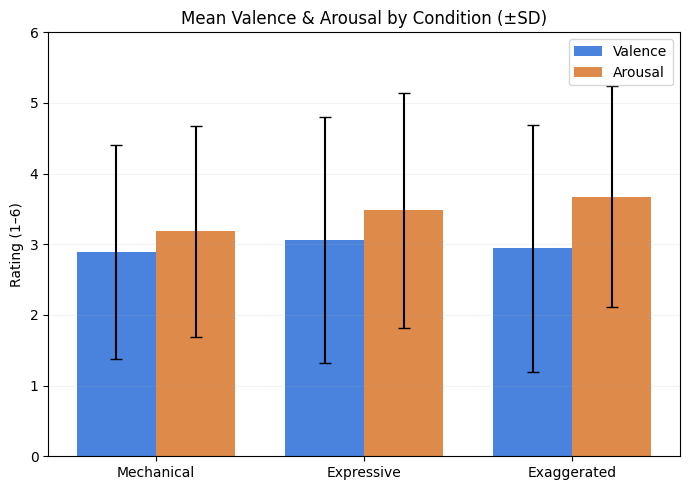


✅ Saved: participant_stats_by_condition.csv, fig_va_by_condition.png, participant_posthoc_tests.csv


In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# Section 1 — Statistical Emotion Analysis (participants only, no classifiers)
# ═══════════════════════════════════════════════════════════════════════════════
from scipy.stats import friedmanchisquare, wilcoxon, rankdata

# ── Data source: cleaned data if a screening step produced it, else full ──────
if 'df_long_clean' in globals():
    PARTICIPANT_DATA = df_long_clean
    print('ℹ️  Using CLEANED participant data (df_long_clean).')
else:
    PARTICIPANT_DATA = df_long
    print('⚠️  NOTE: no participant screening/cleaning step is applied in this '
          'notebook — using FULL questionnaire data (all participants).')

COND_ORDER = ['MEC', 'EXP', 'EXG']

# ── 1a. Mean & SD of valence / arousal per condition (response-level) ─────────
rows = []
for c in COND_ORDER:
    sub = PARTICIPANT_DATA[PARTICIPANT_DATA['condition'] == c]
    rows.append({
        'condition'     : c,
        'condition_name': CONDITIONS[c],
        'n_responses'   : len(sub),
        'valence_mean'  : sub['valence'].mean(),
        'valence_sd'    : sub['valence'].std(),
        'arousal_mean'  : sub['arousal'].mean(),
        'arousal_sd'    : sub['arousal'].std(),
    })
df_cond_stats = pd.DataFrame(rows)
print('\n── Valence / Arousal by condition (participant responses) ──')
print(df_cond_stats.to_string(index=False))

# ── 1b. Emotion-label frequency per condition (RAW participant tags) ──────────
freq = {c: Counter() for c in COND_ORDER}
ntag = {c: 0 for c in COND_ORDER}
for _, r in PARTICIPANT_DATA.iterrows():
    for t in (r['emotion_tags'] if isinstance(r['emotion_tags'], list) else []):
        freq[r['condition']][t] += 1
        ntag[r['condition']]    += 1
df_emo_freq = pd.DataFrame({c: {e: freq[c].get(e, 0) for e in EMOTION_LABELS}
                            for c in COND_ORDER}).reindex(EMOTION_LABELS)
print('\n── Emotion-tag counts per condition (raw participant votes) ──')
print(df_emo_freq.to_string())
denom = pd.Series({c: ntag[c] for c in COND_ORDER})
df_emo_freq_pct = df_emo_freq.divide(denom, axis=1) * 100
print('\n── Emotion-tag share per condition (% of all tags cast in that condition) ──')
print(df_emo_freq_pct.round(1).to_string())

# ── 1c. Friedman (repeated-measures) on PIECE-LEVEL condition means ───────────
# Same 20 pieces appear in all three conditions → within-subject (piece) design.
piece_val = df_agg.pivot(index='piece', columns='condition', values='valence_mean')[COND_ORDER].dropna()
piece_aro = df_agg.pivot(index='piece', columns='condition', values='arousal_mean')[COND_ORDER].dropna()

def kendall_w(chi2, n, k):
    return chi2 / (n * (k - 1))                      # Friedman effect size

def rank_biserial(x, y):
    d = np.asarray(x, float) - np.asarray(y, float)
    d = d[d != 0]
    if len(d) == 0: return 0.0
    r = rankdata(np.abs(d))
    Rpos, Rneg = r[d > 0].sum(), r[d < 0].sum()
    return (Rpos - Rneg) / (Rpos + Rneg)             # matched-pairs rank-biserial

def stars(p):
    return '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'n.s.'

posthoc_rows = []
for name, mat in [('Valence', piece_val), ('Arousal', piece_aro)]:
    n, k = mat.shape
    chi2, p = friedmanchisquare(*[mat[c].values for c in COND_ORDER])
    W = kendall_w(chi2, n, k)
    print(f'\n── Friedman — {name} (piece-level, N={n} pieces, k={k}) ──')
    print(f'   chi2={chi2:.3f}  p={p:.4f} {stars(p)}   Kendall W={W:.3f}')
    if p < .05:
        print('   Post-hoc Wilcoxon signed-rank (Bonferroni x3):')
        for a, b in [('MEC', 'EXP'), ('EXP', 'EXG'), ('MEC', 'EXG')]:
            stat, pw = wilcoxon(mat[a].values, mat[b].values)
            p_bonf = min(pw * 3, 1.0)
            rb = rank_biserial(mat[a].values, mat[b].values)
            print(f'     {a} vs {b}: W={stat:.1f}  p={pw:.4f}  p_bonf={p_bonf:.4f} '
                  f'{stars(p_bonf)}  rank-biserial={rb:+.3f}')
            posthoc_rows.append({'measure': name, 'pair': f'{a}-{b}', 'wilcoxon_W': stat,
                                 'p_raw': pw, 'p_bonferroni': p_bonf, 'rank_biserial': rb})
    else:
        print('   Friedman not significant → post-hoc skipped.')

# ── 1d. Grouped bar chart: mean valence & arousal by condition (±SD) ──────────
fig, ax = plt.subplots(figsize=(7, 5))
xpos, w = np.arange(len(COND_ORDER)), 0.38
ax.bar(xpos - w/2, df_cond_stats['valence_mean'], w, yerr=df_cond_stats['valence_sd'],
       capsize=4, label='Valence', color='#2a6dd9', alpha=0.85)
ax.bar(xpos + w/2, df_cond_stats['arousal_mean'], w, yerr=df_cond_stats['arousal_sd'],
       capsize=4, label='Arousal', color='#d9762a', alpha=0.85)
ax.set_xticks(xpos); ax.set_xticklabels([CONDITIONS[c] for c in COND_ORDER])
ax.set_ylabel('Rating (1–6)'); ax.set_ylim(0, 6)
ax.set_title('Mean Valence & Arousal by Condition (±SD)')
ax.legend(); ax.grid(axis='y', alpha=0.15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_va_by_condition.png'), dpi=150, bbox_inches='tight'); plt.show()

# ── Save tables ───────────────────────────────────────────────────────────────
df_cond_stats.to_csv(os.path.join(OUTPUT_DIR, 'participant_stats_by_condition.csv'), index=False)
if posthoc_rows:
    pd.DataFrame(posthoc_rows).to_csv(os.path.join(OUTPUT_DIR, 'participant_posthoc_tests.csv'), index=False)
print('\n✅ Saved: participant_stats_by_condition.csv, fig_va_by_condition.png'
      + (', participant_posthoc_tests.csv' if posthoc_rows else ''))

## 6B. Lift Analysis — Emotion–Condition Binding
Quantifies how strongly each emotion is bound to each playing condition:

$$\text{lift}(e, c) = \frac{P(e \mid c)}{P(e)}$$

where each probability is the **fraction of excerpts carrying emotion label $e$**.
An excerpt "carries" $e$ if at least a threshold fraction of its raters tagged $e$
(primary threshold **0.30**, with a sensitivity sweep over 0.20 / 0.30 / 0.40 and a
threshold-free mean-vote-share robustness check).

- `lift = 1` → emotion independent of condition
- `lift > 1` → emotion **concentrated** in that condition
- `lift < 1` → emotion **suppressed**

> Uses **raw participant tags** (see note in §6A) — VA-derived labels are avoided to
> prevent circularity (MEC is forced to `Neutral` by rule).

── Lift matrix (emotion × condition) @ threshold=0.30 ──
   lift=1 independent · >1 concentrated · <1 suppressed · NaN = emotion never crosses threshold
                    MEC   EXP   EXG
Tenderness         1.00  1.20  0.80
Nostalgia          0.92  1.04  1.04
Peacefulness       0.86  1.71  0.43
Power              0.57  1.14  1.29
Joyful Activation  0.92  0.92  1.15
Tension            0.87  0.97  1.16
Sadness            1.00  0.91  1.09
Neutral            3.00  0.00  0.00


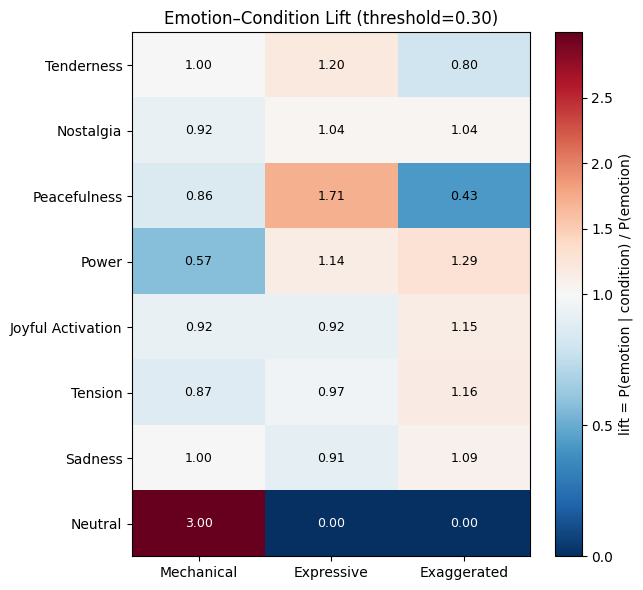


── Top-2 emotions by lift per condition (threshold=0.30) ──
   Mechanical  : Neutral (3.00), Tenderness (1.00)
   Expressive  : Peacefulness (1.71), Tenderness (1.20)
   Exaggerated : Power (1.29), Tension (1.16)

── Threshold sensitivity of top-emotion-per-condition ──
  condition                 top@0.20            top@0.30            top@0.40 stable
 Mechanical           Neutral (2.54)      Neutral (3.00)      Neutral (3.00)    yes
 Expressive Joyful Activation (1.24) Peacefulness (1.71) Peacefulness (2.00)     no
Exaggerated           Tension (1.11)        Power (1.29)        Power (1.41)     no

── Robustness check — threshold-free lift (mean vote-share) ──
                    MEC   EXP   EXG
Tenderness         0.96  1.16  0.88
Nostalgia          0.88  1.05  1.07
Peacefulness       1.13  1.23  0.64
Power              0.71  1.10  1.19
Joyful Activation  0.93  1.06  1.02
Tension            0.86  0.96  1.18
Sadness            0.87  1.06  1.07
Neutral            1.82  0.62  0.57

✅ S

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# Section 2 — Lift Analysis (emotion–condition binding, participants only)
# ═══════════════════════════════════════════════════════════════════════════════
from matplotlib.colors import TwoSlopeNorm
# Uses PARTICIPANT_DATA, COND_ORDER from §6A. Raw tags — NOT VA-derived labels.

def _cond_of(eid):
    return next((c for c in COND_ORDER if eid.endswith('_' + c)), 'UNKNOWN')

def build_incidence(data, thresh):
    """Binary (excerpt × emotion): excerpt carries e if >= thresh of its raters voted e."""
    inc = {}
    for eid, g in data.groupby('excerpt_id'):
        nres   = len(g)
        counts = Counter(t for tags in g['emotion_tags'] if isinstance(tags, list) for t in tags)
        inc[eid] = {e: int(nres > 0 and counts.get(e, 0) / nres >= thresh) for e in EMOTION_LABELS}
    df = pd.DataFrame(inc).T.reindex(columns=EMOTION_LABELS)
    df['condition'] = [_cond_of(eid) for eid in df.index]
    return df

def lift_from_incidence(incidence):
    """lift[e, c] = P(e|c) / P(e overall); probs = fraction of excerpts carrying e."""
    overall = incidence[EMOTION_LABELS].mean(axis=0).replace(0, np.nan)   # P(e)
    lift = pd.DataFrame(index=EMOTION_LABELS, columns=COND_ORDER, dtype=float)
    for c in COND_ORDER:
        sub = incidence[incidence['condition'] == c][EMOTION_LABELS]
        lift[c] = sub.mean(axis=0) / overall                              # P(e|c) / P(e)
    return lift

PRIMARY_THRESH         = 0.30
SENSITIVITY_THRESHOLDS = [0.20, 0.30, 0.40]

lift_by_thresh = {t: lift_from_incidence(build_incidence(PARTICIPANT_DATA, t))
                  for t in SENSITIVITY_THRESHOLDS}
df_lift = lift_by_thresh[PRIMARY_THRESH]

print(f'── Lift matrix (emotion × condition) @ threshold={PRIMARY_THRESH:.2f} ──')
print('   lift=1 independent · >1 concentrated · <1 suppressed · NaN = emotion never crosses threshold')
print(df_lift.round(2).to_string())
df_lift.to_csv(os.path.join(OUTPUT_DIR, 'lift_matrix.csv'))

# ── Heatmap (primary threshold), diverging around lift=1 ──────────────────────
M = df_lift.values.astype(float)
finite = M[np.isfinite(M)]
vmax = max(1.6, float(np.nanmax(finite))) if finite.size else 1.6
vmin = min(0.4, float(np.nanmin(finite))) if finite.size else 0.4
norm = TwoSlopeNorm(vmin=vmin, vcenter=1.0, vmax=vmax)
fig, ax = plt.subplots(figsize=(6.5, 6))
im = ax.imshow(np.ma.masked_invalid(M), cmap='RdBu_r', norm=norm, aspect='auto')
ax.set_xticks(range(len(COND_ORDER))); ax.set_xticklabels([CONDITIONS[c] for c in COND_ORDER])
ax.set_yticks(range(len(EMOTION_LABELS))); ax.set_yticklabels(EMOTION_LABELS)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        v = M[i, j]
        ax.text(j, i, '—' if not np.isfinite(v) else f'{v:.2f}', ha='center', va='center',
                fontsize=9, color='white' if (np.isfinite(v) and (v >= vmax*0.85 or v <= vmin*1.15)) else 'black')
ax.set_title(f'Emotion–Condition Lift (threshold={PRIMARY_THRESH:.2f})')
fig.colorbar(im, ax=ax, label='lift = P(emotion | condition) / P(emotion)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_lift_heatmap.png'), dpi=150, bbox_inches='tight'); plt.show()

# ── Interpretation: top-2 emotions by lift per condition (primary threshold) ──
print(f'\n── Top-2 emotions by lift per condition (threshold={PRIMARY_THRESH:.2f}) ──')
for c in COND_ORDER:
    s = df_lift[c].dropna().sort_values(ascending=False)
    print(f'   {CONDITIONS[c]:<12}: ' + ', '.join(f'{e} ({v:.2f})' for e, v in s.head(2).items()))

# ── Sensitivity: is the TOP emotion per condition stable across thresholds? ───
sens_rows = []
for c in COND_ORDER:
    row, tops = {'condition': CONDITIONS[c]}, []
    for t in SENSITIVITY_THRESHOLDS:
        s = lift_by_thresh[t][c].dropna().sort_values(ascending=False)
        top_e = s.index[0] if len(s) else '—'
        row[f'top@{t:.2f}'] = top_e if not len(s) else f'{top_e} ({s.iloc[0]:.2f})'
        tops.append(top_e)
    row['stable'] = 'yes' if len(set(tops)) == 1 else 'no'
    sens_rows.append(row)
df_sens = pd.DataFrame(sens_rows)
print('\n── Threshold sensitivity of top-emotion-per-condition ──')
print(df_sens.to_string(index=False))
df_sens.to_csv(os.path.join(OUTPUT_DIR, 'lift_threshold_sensitivity.csv'), index=False)

# ── Robustness: threshold-free lift using mean vote-share per excerpt ─────────
share_rows = {}
for eid, g in PARTICIPANT_DATA.groupby('excerpt_id'):
    nres   = len(g)
    counts = Counter(t for tags in g['emotion_tags'] if isinstance(tags, list) for t in tags)
    share_rows[eid] = {e: (counts.get(e, 0) / nres if nres else 0.0) for e in EMOTION_LABELS}
share = pd.DataFrame(share_rows).T.reindex(columns=EMOTION_LABELS)
share['condition'] = [_cond_of(eid) for eid in share.index]
overall_share = share[EMOTION_LABELS].mean(axis=0).replace(0, np.nan)
lift_share = pd.DataFrame(index=EMOTION_LABELS, columns=COND_ORDER, dtype=float)
for c in COND_ORDER:
    lift_share[c] = share[share['condition'] == c][EMOTION_LABELS].mean(axis=0) / overall_share
print('\n── Robustness check — threshold-free lift (mean vote-share) ──')
print(lift_share.round(2).to_string())
lift_share.to_csv(os.path.join(OUTPUT_DIR, 'lift_matrix_meanshare.csv'))

print('\n✅ Saved: lift_matrix.csv, fig_lift_heatmap.png, '
      'lift_threshold_sensitivity.csv, lift_matrix_meanshare.csv')

## 7. MERT — SSL Embedding (768-dim)
Music-specific self-supervised transformer. CQT teacher captures violin pitch micro-variations.  
Layers 5–7 are best for emotion-related tasks (per MERT paper probing experiments).

In [10]:
print('Loading MERT-v1-95M...')
mert_proc  = AutoProcessor.from_pretrained(MERT_MODEL_ID, trust_remote_code=True)
mert_model = AutoModel.from_pretrained(
    MERT_MODEL_ID, trust_remote_code=True, output_hidden_states=True
).to(DEVICE)
mert_model.eval()
for p in mert_model.parameters(): p.requires_grad = False
print(f'✅ MERT loaded ({sum(p.numel() for p in mert_model.parameters())/1e6:.1f}M params)')

def extract_mert(audio_path):
    y, _ = librosa.load(audio_path, sr=SAMPLE_RATE, mono=True)
    inp   = mert_proc(y, sampling_rate=SAMPLE_RATE, return_tensors='pt', padding=True)
    inp   = {k: v.to(DEVICE) for k,v in inp.items()}
    with torch.no_grad():
        out = mert_model(**inp)
    return np.mean([out.hidden_states[l].mean(1).squeeze(0).cpu().numpy() for l in MERT_LAYERS], axis=0)

CACHE_MERT = os.path.join(OUTPUT_DIR, 'emb_mert.npz')
if os.path.exists(CACHE_MERT):
    print('📂 Loading cached MERT embeddings')
    emb_mert = {str(k): v for k,v in np.load(CACHE_MERT, allow_pickle=True).items()}
else:
    print('🔄 Extracting MERT embeddings (~10 min on T4)...')
    emb_mert = {}
    for eid, fp in tqdm(audio_files.items(), desc='MERT'):
        try: emb_mert[eid] = extract_mert(fp)
        except Exception as e: print(f'  ⚠️  {eid}: {e}')
    np.savez(CACHE_MERT, **emb_mert)
    print(f'✅ Saved: {CACHE_MERT}')
print(f'MERT: {len(emb_mert)} excerpts  dim={list(emb_mert.values())[0].shape[0]}')

Loading MERT-v1-95M...


preprocessor_config.json:   0%|          | 0.00/211 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

configuration_MERT.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/m-a-p/MERT-v1-95M:
- configuration_MERT.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Some weights of the model checkpoint at m-a-p/MERT-v1-95M were not used when initializing MERTModel: ['encoder.pos_conv_embed.conv.weight_g', 'encoder.pos_conv_embed.conv.weight_v']
- This IS expected if you are initializing MERTModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing MERTModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of MERTModel were not initialized from the model checkpoint at m-a-p/MERT-v1-95M and are newly initialized: ['encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'encoder.pos_conv_embed.conv.parametrizations.weight.original1']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ MERT loaded (94.4M params)
🔄 Extracting MERT embeddings (~10 min on T4)...


MERT: 100%|██████████| 60/60 [00:19<00:00,  3.07it/s]

✅ Saved: /kaggle/working/pipeline_outputs/emb_mert.npz
MERT: 60 excerpts  dim=768


## 8. CREPE — Pitch Contour / Vibrato / Portamento

In [11]:
def extract_crepe_features(audio_path, step_ms=10):
    y16, _ = librosa.load(audio_path, sr=16000, mono=True)
    _, freq, conf, _ = crepe.predict(y16, 16000, viterbi=True, step_size=step_ms, verbose=0)

    freq, conf = np.array(freq, float), np.array(conf, float)
    voiced = (conf > 0.5) & (freq > 0)
    vf_ratio = voiced.mean()
    if voiced.sum() < 20:
        return {k: 0.0 for k in ['crepe_vibrato_rate_hz','crepe_vibrato_depth_cents',
                                  'crepe_portamento_count','crepe_portamento_mean_ext_cents',
                                  'crepe_f0_range_cents','crepe_f0_cv','crepe_f0_mean_hz',
                                  'crepe_voiced_fraction']} | {'crepe_voiced_fraction': float(vf_ratio)}
    f0v   = freq[voiced]
    cents = 1200 * np.log2(np.clip(f0v, 1e-6, None) / 440)
    fs_f0 = 1000 / step_ms
    if fs_f0 / 2 > 8:
        nyq = fs_f0 / 2
        b, a = butter(4, [4/nyq, 8/nyq], btype='band')
        vs = filtfilt(b, a, cents)
        vdepth = float(np.std(vs) * 2)
        fr, ps = welch(vs, fs=fs_f0, nperseg=min(256, len(vs)))
        band   = (fr >= 4) & (fr <= 8)
        vrate  = float(fr[band][np.argmax(ps[band])]) if band.sum() > 0 else 0.0
    else:
        vrate = vdepth = 0.0
    diff = np.abs(np.diff(cents))
    thresh = 50 / (100 / fs_f0)
    evts, run, rsum = [], 0, 0.0
    for v, flag in zip(diff, diff > thresh):
        if flag: run += 1; rsum += v
        else:
            if run >= 5: evts.append(rsum)
            run = rsum = 0
    return {
        'crepe_vibrato_rate_hz'          : vrate,
        'crepe_vibrato_depth_cents'      : vdepth,
        'crepe_portamento_count'         : float(len(evts)),
        'crepe_portamento_mean_ext_cents': float(np.mean(evts)) if evts else 0.0,
        'crepe_f0_range_cents'           : float(cents.max() - cents.min()),
        'crepe_f0_cv'                    : float(np.std(f0v) / (np.mean(f0v) + 1e-9)),
        'crepe_f0_mean_hz'               : float(np.mean(f0v)),
        'crepe_voiced_fraction'          : float(vf_ratio),
    }

CACHE_CREPE = os.path.join(OUTPUT_DIR, 'feat_crepe.csv')
if os.path.exists(CACHE_CREPE):
    df_crepe = pd.read_csv(CACHE_CREPE, index_col='excerpt_id')
    print(f'📂 Loaded CREPE cache  {df_crepe.shape}')
else:
    print('🔄 Extracting CREPE features...')
    df_crepe = pd.DataFrame({e: extract_crepe_features(p) for e,p in tqdm(audio_files.items(), desc='CREPE')}).T
    df_crepe.index.name = 'excerpt_id'; df_crepe.to_csv(CACHE_CREPE)
    print(f'✅ Saved  {df_crepe.shape}')

🔄 Extracting CREPE features...


CREPE:   0%|          | 0/60 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1783006275.481393      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13597 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1783006280.233057     198 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
CREPE:   2%|▏         | 1/60 [00:07<07:21,  7.48s/it]2026-07-02 15:31:24.589838: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-02 15:31:24.825168: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execu

✅ Saved  (60, 8)


## 9. madmom — Onset Detection / IOI / Timing Deviations

In [12]:
# ── Madmom — SKIPPED (validation mode: MERT + CREPE only) ───────────────────
# Re-enable for full pipeline run.
print('⏭  Madmom skipped (validation mode)')

⏭  Madmom skipped (validation mode)


## 10. DTW Alignment — Warp Path Statistics

In [13]:
# ── DTW Alignment — SKIPPED (validation mode: MERT + CREPE only) ─────────────
print('⏭  DTW skipped (validation mode)')

⏭  DTW skipped (validation mode)


## 11. Essentia DSP — Loudness / Spectral Timbre

In [14]:
# ── Essentia DSP — SKIPPED (validation mode: MERT + CREPE only) ──────────────
print('⏭  Essentia DSP skipped (validation mode)')

⏭  Essentia DSP skipped (validation mode)


## 12. Essentia MusiCNN — DNN Embedding (200-dim)

In [15]:
# ── MusiCNN — SKIPPED (validation mode: MERT + CREPE only) ───────────────────
print('⏭  MusiCNN skipped (validation mode)')

⏭  MusiCNN skipped (validation mode)


## 13. Assemble Three Feature Matrices
| Set | Sources | Purpose |
|---|---|---|
| **A** | MERT + MusiCNN                    | SSL embeddings only |
| **B** | CREPE + madmom + Essentia DSP + DTW | Low-level acoustic only |
| **C** | A + B | Combined |

In [16]:
def bfv(eid, feat_sets):
    parts=[]
    for _,src,kind in feat_sets:
        if kind=='emb':
            v=src.get(eid); v=np.zeros(list(src.values())[0].flatten().shape) if v is None else v
        else:
            v=src.loc[eid].values.astype(float) if eid in src.index else np.zeros(src.shape[1])
        parts.append(np.array(v,dtype=np.float32).flatten())
    return np.concatenate(parts)

eids    = df_expr['excerpt_id'].tolist()
# ── Validation mode: one SSL (MERT) + one low-level (CREPE) ─────────────────
FEAT_A  = [('MERT',  emb_mert, 'emb')]
FEAT_B  = [('CREPE', df_crepe, 'tab')]
FEAT_C  = FEAT_A + FEAT_B

X_A = np.array([bfv(e,FEAT_A) for e in eids])
X_B = np.array([bfv(e,FEAT_B) for e in eids])
X_C = np.array([bfv(e,FEAT_C) for e in eids])

for nm, X in [('A',X_A),('B',X_B),('C',X_C)]:
    if np.isnan(X).any():
        cm=np.nanmean(X,axis=0); idx=np.where(np.isnan(X)); X[idx]=np.take(cm,idx[1])
        print(f'⚠️  Set {nm}: NaNs imputed')
print(f'Set A (SSL):      {X_A.shape}')
print(f'Set B (Low-level):{X_B.shape}')
print(f'Set C (Combined): {X_C.shape}')

Set A (SSL):      (60, 768)
Set B (Low-level):(60, 8)
Set C (Combined): (60, 776)


## 14. Multi-Label Classification — 8 Classifiers × 3 Feature Sets × LOOCV
**Research question operationalised:**  
A > B → scale beats domain features &nbsp;|&nbsp; B > A → acoustic features win &nbsp;|&nbsp; C > A,B → fusion is complementary

In [17]:
# ── SafeMultiOutputClassifier ─────────────────────────────────────────────────
# LOOCV with N=40 and 8 rare emotion labels means some label columns will be
# all-zeros in a given training fold (e.g. a label present in only 1-2 samples).
# sklearn's SVC/SVM raises ValueError when it sees only 1 class.
# This wrapper silently predicts the majority class (always 0) for such columns
# instead of crashing — scientifically equivalent to "no positive evidence found".
from sklearn.base import BaseEstimator, ClassifierMixin, clone as sk_clone

class SafeMultiOutputClassifier(BaseEstimator, ClassifierMixin):
    """MultiOutputClassifier robust to single-class label columns in LOOCV folds."""
    def __init__(self, estimator):
        self.estimator = estimator

    def fit(self, X, Y):
        self.n_outputs_ = Y.shape[1]
        self.estimators_ = []
        self.majority_    = []
        for j in range(self.n_outputs_):
            y_col = Y[:, j]
            maj   = int(y_col.mean() >= 0.5)
            self.majority_.append(maj)
            if len(np.unique(y_col)) < 2:
                self.estimators_.append(None)   # degenerate — predict constant
            else:
                est = sk_clone(self.estimator)
                est.fit(X, y_col)
                self.estimators_.append(est)
        return self

    def predict(self, X):
        preds = []
        for j, est in enumerate(self.estimators_):
            if est is None:
                preds.append(np.full(len(X), self.majority_[j], dtype=int))
            else:
                preds.append(est.predict(X).astype(int))
        return np.column_stack(preds)

def make_clfs():
    return {
        'SVM-Linear'  : SVC(kernel='linear',C=1.0,probability=True),
        'SVM-RBF'     : SVC(kernel='rbf',   C=1.0,probability=True),
        'LogReg'      : LogisticRegression(C=0.1,max_iter=2000),
        'RandomForest': RandomForestClassifier(n_estimators=200,max_depth=6,random_state=42,n_jobs=-1),
        'ExtraTrees'  : ExtraTreesClassifier(n_estimators=200,max_depth=6,random_state=42,n_jobs=-1),
        'KNN'         : KNeighborsClassifier(n_neighbors=5,metric='cosine'),
        'NaiveBayes'  : GaussianNB(),
    }

def run_set(X_feat, Y_tgt, set_name):
    loo = LeaveOneOut(); recs = []
    print(f'\n── {set_name}  X={X_feat.shape} ──')
    for name, clf in make_clfs().items():
        print(f'  {name}...', end=' ', flush=True)
        Yp = cross_val_predict(
            Pipeline([('sc',StandardScaler()),('clf',SafeMultiOutputClassifier(clf))]),
            X_feat, Y_tgt, cv=loo, n_jobs=1)
        hl=hamming_loss(Y_tgt,Yp); f1m=f1_score(Y_tgt,Yp,average='macro',zero_division=0)
        f1i=f1_score(Y_tgt,Yp,average='micro',zero_division=0)
        sa=(Y_tgt==Yp).all(axis=1).mean()
        print(f'HL={hl:.3f} F1m={f1m:.3f}')
        recs.append({'feature_set':set_name,'classifier':name,'hamming_loss':hl,
                     'f1_macro':f1m,'f1_micro':f1i,'subset_acc':sa,'Y_pred':Yp})
    # XGBoost binary relevance — already guards yl.sum()<2, no change needed
    print(f'  XGBoost...', end=' ', flush=True)
    Yp_xgb = np.zeros_like(Y_tgt)
    for li in range(Y_tgt.shape[1]):
        yl=Y_tgt[:,li]
        if yl.sum()<2: continue
        xgb=XGBClassifier(n_estimators=100,max_depth=4,learning_rate=0.1,subsample=0.8,
                          colsample_bytree=0.8,eval_metric='logloss',random_state=42,n_jobs=-1)
        Yp_xgb[:,li]=cross_val_predict(Pipeline([('sc',StandardScaler()),('clf',xgb)]),X_feat,yl,cv=loo)
    hl=hamming_loss(Y_tgt,Yp_xgb); f1m=f1_score(Y_tgt,Yp_xgb,average='macro',zero_division=0)
    print(f'HL={hl:.3f} F1m={f1m:.3f}')
    recs.append({'feature_set':set_name,'classifier':'XGBoost','hamming_loss':hl,
                 'f1_macro':f1m,'f1_micro':f1_score(Y_tgt,Yp_xgb,average='micro',zero_division=0),
                 'subset_acc':(Y_tgt==Yp_xgb).all(axis=1).mean(),'Y_pred':Yp_xgb})
    return recs

all_recs  = run_set(X_A, Y, 'A: MERT')
all_recs += run_set(X_B, Y, 'B: CREPE')
all_recs += run_set(X_C, Y, 'C: Combined')
print('\n✅ Validation experiments complete (3 sets × 8 classifiers + XGBoost)')


── A: MERT  X=(60, 768) ──
  SVM-Linear... HL=0.092 F1m=0.736
  SVM-RBF... HL=0.167 F1m=0.065
  LogReg... HL=0.102 F1m=0.613
  RandomForest... HL=0.135 F1m=0.329
  ExtraTrees... HL=0.127 F1m=0.407
  KNN... HL=0.165 F1m=0.289
  NaiveBayes... HL=0.154 F1m=0.453
  XGBoost... HL=0.135 F1m=0.377

── B: CREPE  X=(60, 8) ──
  SVM-Linear... HL=0.190 F1m=0.179
  SVM-RBF... HL=0.188 F1m=0.088
  LogReg... HL=0.179 F1m=0.081
  RandomForest... HL=0.215 F1m=0.104
  ExtraTrees... HL=0.200 F1m=0.088
  KNN... HL=0.212 F1m=0.190
  NaiveBayes... HL=0.198 F1m=0.317
  XGBoost... HL=0.208 F1m=0.206

── C: Combined  X=(60, 776) ──
  SVM-Linear... HL=0.094 F1m=0.729
  SVM-RBF... HL=0.167 F1m=0.065
  LogReg... HL=0.102 F1m=0.613
  RandomForest... HL=0.142 F1m=0.280
  ExtraTrees... HL=0.133 F1m=0.375
  KNN... HL=0.169 F1m=0.281
  NaiveBayes... HL=0.154 F1m=0.453
  XGBoost... HL=0.131 F1m=0.407

✅ Validation experiments complete (3 sets × 8 classifiers + XGBoost)


## 15. VA Regression (Head 1)

In [18]:
conditions  = df_expr['condition'].values
y_valence   = df_expr['valence_mean'].values
y_arousal   = df_expr['arousal_mean'].values
loo         = LeaveOneOut()
REG = {'Ridge':Ridge(alpha=10.0),'SVR':SVR(kernel='rbf',C=1.0,epsilon=0.3),
       'MLP':MLPRegressor(hidden_layer_sizes=(256,64),alpha=0.01,max_iter=1000,random_state=42)}
reg_res = {}
print(f"\n{'Model':<8} {'Val r':>7} {'Aro r':>7} {'Val RMSE':>10} {'Aro RMSE':>10}")
print('-'*46)
for nm, reg in REG.items():
    vp=cross_val_predict(Pipeline([('sc',StandardScaler()),('r',reg)]),X_A,y_valence,cv=loo,n_jobs=-1)
    ap=cross_val_predict(Pipeline([('sc',StandardScaler()),('r',reg)]),X_A,y_arousal, cv=loo,n_jobs=-1)
    vr,_=pearsonr(y_valence,vp); ar,_=pearsonr(y_arousal,ap)
    vrmse=np.sqrt(mean_squared_error(y_valence,vp)); armse=np.sqrt(mean_squared_error(y_arousal,ap))
    reg_res[nm]={'vp':vp,'ap':ap,'vr':vr,'ar':ar,'vrmse':vrmse,'armse':armse}
    print(f'{nm:<8} {vr:>7.3f} {ar:>7.3f} {vrmse:>10.3f} {armse:>10.3f}')


Model      Val r   Aro r   Val RMSE   Aro RMSE
----------------------------------------------
Ridge      0.863   0.863      0.538      0.491
SVR        0.811   0.882      0.723      0.507
MLP        0.712   0.736      0.826      0.776


## 16. Heuristic Baseline (MFCC + SVM)

In [19]:
def acoustic_features(fp):
    y,sr=librosa.load(fp,sr=22050,mono=True)
    return np.concatenate([
        librosa.feature.mfcc(y=y,sr=sr,n_mfcc=13).mean(axis=1),
        [librosa.feature.rms(y=y).mean(),
         librosa.feature.spectral_centroid(y=y,sr=sr).mean(),
         librosa.feature.spectral_rolloff(y=y,sr=sr).mean(),
         librosa.feature.zero_crossing_rate(y=y).mean(),
         float(librosa.beat.beat_track(y=y,sr=sr)[0])]
    ])

print('Extracting baseline features...')
X_base = np.array([acoustic_features(audio_files[e]) for e in tqdm(eids)])
Yp_bl  = cross_val_predict(
    Pipeline([('sc',StandardScaler()),('clf',SafeMultiOutputClassifier(SVC(kernel='rbf',C=1.0)))]),
    X_base, Y, cv=loo)
bl_hl  = hamming_loss(Y, Yp_bl)
bl_f1m = f1_score(Y, Yp_bl, average='macro', zero_division=0)
print(f'Baseline MFCC+SVM:  Hamming={bl_hl:.4f}  F1-macro={bl_f1m:.4f}')

Extracting baseline features...


100%|██████████| 60/60 [00:22<00:00,  2.64it/s]


Baseline MFCC+SVM:  Hamming=0.2021  F1-macro=0.0000


## 17. Results — Ablation Table + Wilcoxon

In [20]:
df_abl = pd.DataFrame([{'Feature Set':r['feature_set'],'Classifier':r['classifier'],
    'Hamming ↓':r['hamming_loss'],'F1-macro ↑':r['f1_macro'],
    'F1-micro ↑':r['f1_micro'],'Subset Acc ↑':r['subset_acc']} for r in all_recs])
pivot_f1 = df_abl.pivot(index='Classifier',columns='Feature Set',values='F1-macro ↑')
pivot_hl = df_abl.pivot(index='Classifier',columns='Feature Set',values='Hamming ↓')

print('\n📊 F1-MACRO')
print(pivot_f1.round(4).to_string())
print('\n📊 HAMMING LOSS')
print(pivot_hl.round(4).to_string())

print('\n📊 WILCOXON (F1-macro, n=8 classifiers)')
print(f"{'Comparison':<12} {'W':>7} {'p':>9} {'Sig':>8}")
for s1,s2 in [('A: MERT','B: CREPE'),
               ('A: MERT','C: Combined'),
               ('B: CREPE','C: Combined')]:
    a,b = pivot_f1[s1].values, pivot_f1[s2].values
    if np.all(a==b): print(f'{s1[-1]} vs {s2[-1]}  identical'); continue
    try:
        w,p=wilcoxon(a,b)
        sig='✅ p<.05' if p<0.05 else 'n.s.'
        print(f'{s1[-1]} vs {s2[-1]}  {w:>7.1f} {p:>9.4f} {sig:>8}')
    except Exception as e: print(f'  {e}')

df_abl.to_csv(os.path.join(OUTPUT_DIR,'ablation_results.csv'),index=False)


📊 F1-MACRO
Feature Set   A: MERT  B: CREPE  C: Combined
Classifier                                  
ExtraTrees     0.4070    0.0882       0.3748
KNN            0.2892    0.1895       0.2810
LogReg         0.6125    0.0812       0.6125
NaiveBayes     0.4531    0.3174       0.4531
RandomForest   0.3293    0.1044       0.2803
SVM-Linear     0.7362    0.1794       0.7290
SVM-RBF        0.0648    0.0882       0.0648
XGBoost        0.3765    0.2059       0.4071

📊 HAMMING LOSS
Feature Set   A: MERT  B: CREPE  C: Combined
Classifier                                  
ExtraTrees     0.1271    0.2000       0.1333
KNN            0.1646    0.2125       0.1688
LogReg         0.1021    0.1792       0.1021
NaiveBayes     0.1542    0.1979       0.1542
RandomForest   0.1354    0.2146       0.1417
SVM-Linear     0.0917    0.1896       0.0938
SVM-RBF        0.1667    0.1875       0.1667
XGBoost        0.1354    0.2083       0.1312

📊 WILCOXON (F1-macro, n=8 classifiers)
Comparison         W         p  

## 18. Analysis A — Per-Condition F1

In [21]:
best_r = max(all_recs, key=lambda r: r['f1_macro'])
print(f'Best overall: {best_r["feature_set"]} / {best_r["classifier"]}  F1-macro={best_r["f1_macro"]:.4f}')
print(f'\nPer-condition F1-macro (best model):')
for cond in ['MEC','EXP','EXG']:
    mask=conditions==cond
    if mask.sum()<2: continue
    f1=f1_score(Y[mask],best_r['Y_pred'][mask],average='macro',zero_division=0)
    print(f'  {cond} ({CONDITIONS[cond]}): {f1:.4f}')

Best overall: A: MERT / SVM-Linear  F1-macro=0.7362

Per-condition F1-macro (best model):
  MEC (Mechanical): 0.1149
  EXP (Expressive): 0.5871
  EXG (Exaggerated): 0.7439


## 19. Analysis B — Quadrant Accuracy

Quadrant accuracy (Ridge VA → circumplex): 0.7000


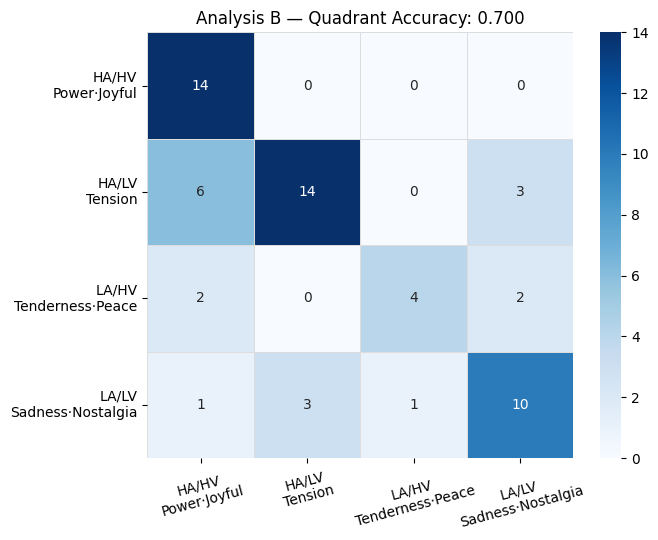

In [22]:
pred_v = reg_res['Ridge']['vp']; pred_a = reg_res['Ridge']['ap']
pred_quads = np.array([va_to_quadrant(v,a) for v,a in zip(pred_v,pred_a)])
true_quads = df_expr['quadrant'].values
qa = accuracy_score(true_quads, pred_quads)
print(f'Quadrant accuracy (Ridge VA → circumplex): {qa:.4f}')
ql = ['HA_HV','HA_LV','LA_HV','LA_LV']
qn = ['HA/HV\nPower·Joyful','HA/LV\nTension','LA/HV\nTenderness·Peace','LA/LV\nSadness·Nostalgia']
qcm = confusion_matrix(true_quads, pred_quads, labels=ql)
fig,ax=plt.subplots(figsize=(7,5.5))
sns.heatmap(qcm,ax=ax,xticklabels=qn,yticklabels=qn,annot=True,fmt='d',
            cmap='Blues',linewidths=0.4,linecolor='#ddd')
ax.set_title(f'Analysis B — Quadrant Accuracy: {qa:.3f}'); ax.tick_params(axis='x',rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'fig_quadrant_cm.png'),dpi=150,bbox_inches='tight')
plt.show()

## 20. Analysis C — Krippendorff's α

In [23]:
def kripp_alpha(mat):
    nr,ni=mat.shape; tp=dp=0
    for j in range(ni):
        v=mat[:,j]; v=v[~np.isnan(v.astype(float))]; n=len(v)
        if n<2: continue
        for a in range(n):
            for b in range(a+1,n):
                tp+=1; dp+=(v[a]!=v[b])
    Do=dp/tp if tp else 0
    av=mat.flatten(); av=av[~np.isnan(av.astype(float))]
    _,c=np.unique(av.astype(int),return_counts=True); p=c/c.sum()
    De=1-np.sum(p**2)
    return 1-Do/De if De else 1.0

print('Analysis C — Krippendorff\'s α per label (best model vs participant-derived GT)')
print(f"{'Label':<22} {'α':>8}")
print('-'*32)
for li,lbl in enumerate(mlb.classes_):
    mat=np.array([Y[:,li].astype(float), best_r['Y_pred'][:,li].astype(float)])
    print(f'{lbl:<22} {kripp_alpha(mat):>8.4f}')

Analysis C — Krippendorff's α per label (best model vs participant-derived GT)
Label                         α
--------------------------------
Tenderness               0.7321
Nostalgia                0.6400
Peacefulness             0.7321
Power                    0.7917
Joyful Activation        0.7917
Tension                  0.2547
Sadness                  0.6400
Neutral                  0.8460


## 21. Analysis D — Embedding Distance Attribution
**Unique contribution of the within-piece design.**  
How much does MERT embedding shift between conditions? Does it predict ΔArousal?

In [24]:
shifts=[]
for piece in df_all['piece'].unique():
    sub  = df_all[df_all['piece']==piece]
    ids  = {r['condition']:r['excerpt_id'] for _,r in sub.iterrows()}
    if not all(c in ids for c in ['MEC','EXP','EXG']): continue
    if not all(ids[c] in emb_mert for c in ['MEC','EXP','EXG']): continue
    em   = {c: emb_mert[ids[c]] for c in ['MEC','EXP','EXG']}
    lb   = {c: sub[sub['condition']==c].iloc[0] for c in ['MEC','EXP','EXG']}
    shifts.append({
        'piece':piece,
        'dist_ME':np.linalg.norm(em['EXP']-em['MEC']),'dist_EX':np.linalg.norm(em['EXG']-em['EXP']),
        'dval_ME':lb['EXP']['valence_mean']-lb['MEC']['valence_mean'],
        'daro_ME':lb['EXP']['arousal_mean']-lb['MEC']['arousal_mean'],
        'dval_EX':lb['EXG']['valence_mean']-lb['EXP']['valence_mean'],
        'daro_EX':lb['EXG']['arousal_mean']-lb['EXP']['arousal_mean'],
    })
df_sh = pd.DataFrame(shifts)
print('Analysis D — Embedding Distance vs |ΔArousal|')
print(f"{'Transition':<18} {'Dimension':<12} {'r':>8} {'p':>9}")
print('-'*52)
for step,dc,dvc,dac in[('Mech→Expr','dist_ME','dval_ME','daro_ME'),
                        ('Expr→Exag','dist_EX','dval_EX','daro_EX')]:
    for dim,col in[('|ΔValence|',dvc),('|ΔArousal|',dac)]:
        x,y=df_sh[dc].values,np.abs(df_sh[col].values)
        if len(x)>=3:
            r,p=pearsonr(x,y)
            print(f'{step:<18} {dim:<12} {r:>8.3f} {p:>9.4f} {"***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "n.s."}')
df_sh.to_csv(os.path.join(OUTPUT_DIR,'analysis_d_shifts.csv'),index=False)

Analysis D — Embedding Distance vs |ΔArousal|
Transition         Dimension           r         p
----------------------------------------------------
Mech→Expr          |ΔValence|     -0.278    0.2351 n.s.
Mech→Expr          |ΔArousal|     -0.313    0.1787 n.s.
Expr→Exag          |ΔValence|     -0.231    0.3263 n.s.
Expr→Exag          |ΔArousal|      0.028    0.9066 n.s.


## E1. Path B — Condition-Delta: Technique Changes vs Emotion Changes
For each of the 20 pieces compute the **change in every CREPE technique feature**  
between MEC→EXP and EXP→EXG and MEC→EXG, then correlate with ΔValence / ΔArousal from listener ratings.

*Directly answers: "When the performer added more vibrato, did listeners rate it as more arousing?"*

In [25]:
# ═══════════════════════════════════════════════════════════════════════════════
# Path B — Condition-Delta Analysis
# ═══════════════════════════════════════════════════════════════════════════════

CREPE_FEAT_LABELS = {
    'crepe_vibrato_rate_hz'          : 'Vibrato Rate',
    'crepe_vibrato_depth_cents'      : 'Vibrato Depth',
    'crepe_portamento_count'         : 'Portamento Count',
    'crepe_portamento_mean_ext_cents': 'Portamento Extent',
    'crepe_f0_range_cents'           : 'F0 Range',
    'crepe_f0_cv'                    : 'F0 Coeff. Var.',
    'crepe_f0_mean_hz'               : 'F0 Mean',
    'crepe_voiced_fraction'          : 'Voiced Fraction',
}
feat_keys  = list(CREPE_FEAT_LABELS.keys())
feat_short = list(CREPE_FEAT_LABELS.values())

# ── Build piece-level delta dataframe ─────────────────────────────────────────
piece_deltas = []
for piece in df_all['piece'].unique():
    sub  = df_all[df_all['piece'] == piece]
    ids  = {r['condition']: r['excerpt_id'] for _, r in sub.iterrows()}
    if not all(c in ids for c in ['MEC','EXP','EXG']): continue
    feats = {c: (df_crepe.loc[ids[c]] if ids[c] in df_crepe.index else None)
             for c in ['MEC','EXP','EXG']}
    if any(v is None for v in feats.values()): continue
    va = {c: {'val': sub[sub['condition']==c].iloc[0]['valence_mean'],
               'aro': sub[sub['condition']==c].iloc[0]['arousal_mean']}
          for c in ['MEC','EXP','EXG']}
    rec = {'piece': piece}
    for fk in feat_keys:
        rec[f'dME_{fk}'] = float(feats['EXP'][fk]) - float(feats['MEC'][fk])
        rec[f'dEX_{fk}'] = float(feats['EXG'][fk]) - float(feats['EXP'][fk])
        rec[f'dMG_{fk}'] = float(feats['EXG'][fk]) - float(feats['MEC'][fk])
    rec.update({
        'dME_val': va['EXP']['val'] - va['MEC']['val'],
        'dME_aro': va['EXP']['aro'] - va['MEC']['aro'],
        'dEX_val': va['EXG']['val'] - va['EXP']['val'],
        'dEX_aro': va['EXG']['aro'] - va['EXP']['aro'],
        'dMG_val': va['EXG']['val'] - va['MEC']['val'],
        'dMG_aro': va['EXG']['aro'] - va['MEC']['aro'],
    })
    piece_deltas.append(rec)

df_delta = pd.DataFrame(piece_deltas)
print(f'Piece-level delta matrix: {df_delta.shape}  ({len(df_delta)} pieces)')

# ── Correlation matrices ───────────────────────────────────────────────────────
def corr_matrix(df, feat_prefix, target_cols, fkeys):
    r_mat = np.zeros((len(fkeys), len(target_cols)))
    p_mat = np.ones((len(fkeys),  len(target_cols)))
    for i, fk in enumerate(fkeys):
        x = df[f'{feat_prefix}{fk}'].values
        for j, tc in enumerate(target_cols):
            y     = df[tc].values
            valid = ~(np.isnan(x) | np.isnan(y))
            if valid.sum() >= 4:
                r, p = pearsonr(x[valid], y[valid])
                r_mat[i, j] = r; p_mat[i, j] = p
    return r_mat, p_mat

r_ME, p_ME = corr_matrix(df_delta, 'dME_', ['dME_val','dME_aro'], feat_keys)
r_EX, p_EX = corr_matrix(df_delta, 'dEX_', ['dEX_val','dEX_aro'], feat_keys)
r_MG, p_MG = corr_matrix(df_delta, 'dMG_', ['dMG_val','dMG_aro'], feat_keys)

def sig(p): return '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else 'n.s.'

for r_mat, p_mat, title in [
    (r_ME, p_ME, 'MEC → EXP  (Expressive minus Mechanical)'),
    (r_EX, p_EX, 'EXP → EXG  (Exaggerated minus Expressive)'),
    (r_MG, p_MG, 'MEC → EXG  (Exaggerated minus Mechanical)'),
]:
    print(f'\n{title}')
    print(f'  {"Technique":<28} {"ΔValence r (p)":<22} {"ΔArousal r (p)"}')
    print('  ' + '-'*68)
    for i, fs in enumerate(feat_short):
        rv, pv = r_mat[i,0], p_mat[i,0]
        ra, pa = r_mat[i,1], p_mat[i,1]
        print(f'  {fs:<28} r={rv:+.3f} p={pv:.3f} {sig(pv):<6} r={ra:+.3f} p={pa:.3f} {sig(pa)}')

df_delta.to_csv(os.path.join(OUTPUT_DIR,'analysis_condition_deltas.csv'), index=False)
print(f'\n✅ Saved: analysis_condition_deltas.csv')

Piece-level delta matrix: (20, 31)  (20 pieces)

MEC → EXP  (Expressive minus Mechanical)
  Technique                    ΔValence r (p)         ΔArousal r (p)
  --------------------------------------------------------------------
  Vibrato Rate                 r=-0.198 p=0.403 n.s.   r=-0.351 p=0.129 n.s.
  Vibrato Depth                r=+0.334 p=0.149 n.s.   r=+0.208 p=0.380 n.s.
  Portamento Count             r=+0.001 p=0.998 n.s.   r=-0.325 p=0.161 n.s.
  Portamento Extent            r=-0.098 p=0.680 n.s.   r=+0.023 p=0.925 n.s.
  F0 Range                     r=+0.222 p=0.346 n.s.   r=+0.322 p=0.166 n.s.
  F0 Coeff. Var.               r=+0.222 p=0.347 n.s.   r=+0.224 p=0.343 n.s.
  F0 Mean                      r=-0.054 p=0.820 n.s.   r=+0.087 p=0.716 n.s.
  Voiced Fraction              r=-0.075 p=0.754 n.s.   r=-0.172 p=0.469 n.s.

EXP → EXG  (Exaggerated minus Expressive)
  Technique                    ΔValence r (p)         ΔArousal r (p)
  ----------------------------------------

## E2. Path A — SHAP Technique Importance per Emotion
For each emotion label fit a **RandomForest** on the 8 CREPE features (all 60 excerpts).  
**SHAP TreeExplainer** quantifies exactly how much each technique drives each emotion prediction.

*Mean |SHAP| = how much that technique "moves the needle" for that emotion class.*

In [26]:
# ═══════════════════════════════════════════════════════════════════════════════
# Path A — SHAP Feature Importance
# ═══════════════════════════════════════════════════════════════════════════════

scaler_shap  = StandardScaler()
X_B_sc       = scaler_shap.fit_transform(X_B)

# (8 emotions × 8 techniques) — mean absolute SHAP value
shap_mean_abs = np.zeros((len(mlb.classes_), len(feat_keys)))
shap_vals_all = {}   # emotion → (N, 8) raw SHAP for beeswarm

print(f'SHAP  |  {len(X_B)} samples  |  {X_B.shape[1]} features  |  {len(mlb.classes_)} labels')
print('─' * 60)

for j, emotion in enumerate(mlb.classes_):
    y_col = Y[:, j]
    if len(np.unique(y_col)) < 2:
        print(f'  {emotion:<24} — skipped (single class)')
        continue
    rf = RandomForestClassifier(n_estimators=400, max_depth=6,
                                class_weight='balanced', random_state=42, n_jobs=-1)
    rf.fit(X_B_sc, y_col)
    explainer = shap.TreeExplainer(rf)
    sv        = explainer.shap_values(X_B_sc)
    #error fix
    # Extract positive class SHAP values safely across different SHAP versions
    if isinstance(sv, list):
        sv1 = sv[1]                  # Older SHAP versions
    elif len(sv.shape) == 3:
        sv1 = sv[:, :, 1]            # Newer SHAP versions: (samples, features, classes)
    else:
        sv1 = sv                     # Fallback
    shap_vals_all[emotion]  = sv1
    shap_mean_abs[j]        = np.abs(sv1).mean(axis=0)
    top_i = np.argmax(shap_mean_abs[j])
    print(f'  {emotion:<24}  top: {feat_short[top_i]:<26} mean|SHAP|={shap_mean_abs[j,top_i]:.4f}')

df_shap_importance = pd.DataFrame(
    shap_mean_abs,
    index   = list(mlb.classes_),
    columns = feat_short
)
df_shap_importance.to_csv(os.path.join(OUTPUT_DIR,'shap_technique_importance.csv'))
print(f'\n✅ Saved: shap_technique_importance.csv')
print('\nFull matrix (mean |SHAP|):')
print(df_shap_importance.round(4).to_string())

SHAP  |  60 samples  |  8 features  |  8 labels
────────────────────────────────────────────────────────────
  Tenderness                top: F0 Mean                    mean|SHAP|=0.1005
  Nostalgia                 top: F0 Range                   mean|SHAP|=0.1251
  Peacefulness              top: F0 Mean                    mean|SHAP|=0.1005
  Power                     top: Vibrato Depth              mean|SHAP|=0.1122
  Joyful Activation         top: Vibrato Depth              mean|SHAP|=0.1122
  Tension                   top: F0 Coeff. Var.             mean|SHAP|=0.0520
  Sadness                   top: F0 Range                   mean|SHAP|=0.1251
  Neutral                   top: Vibrato Depth              mean|SHAP|=0.0731

✅ Saved: shap_technique_importance.csv

Full matrix (mean |SHAP|):
                   Vibrato Rate  Vibrato Depth  Portamento Count  Portamento Extent  F0 Range  F0 Coeff. Var.  F0 Mean  Voiced Fraction
Tenderness               0.0293         0.0916            0.027

## 22. Figures

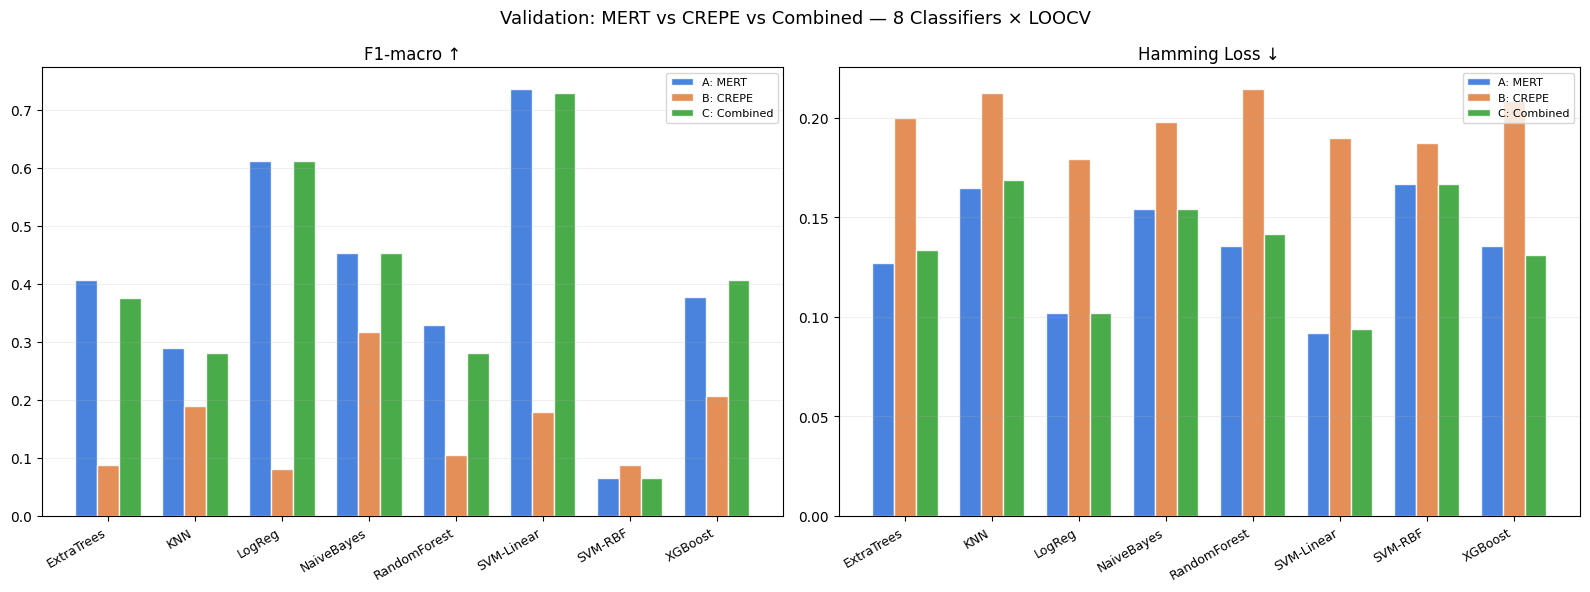

In [27]:
# ── Fig 1: Ablation grouped bar ───────────────────────────────────────────────
clfs=pivot_f1.index.tolist(); sets=pivot_f1.columns.tolist()
x=np.arange(len(clfs)); w=0.25; cols=['#2a6dd9','#e07b39','#2a9d2a']
fig,axes=plt.subplots(1,2,figsize=(16,6))
fig.suptitle('Validation: MERT vs CREPE vs Combined — 8 Classifiers × LOOCV',fontsize=13)
for ax,(piv,title) in zip(axes,[(pivot_f1,'F1-macro ↑'),(pivot_hl,'Hamming Loss ↓')]):
    for i,(s,c) in enumerate(zip(sets,cols)):
        bars=ax.bar(x+(i-1)*w,piv[s].values,w,label=s,color=c,alpha=0.85,edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(clfs,rotation=30,ha='right',fontsize=9)
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(axis='y',alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'fig_ablation_bar.png'),dpi=150,bbox_inches='tight'); plt.show()

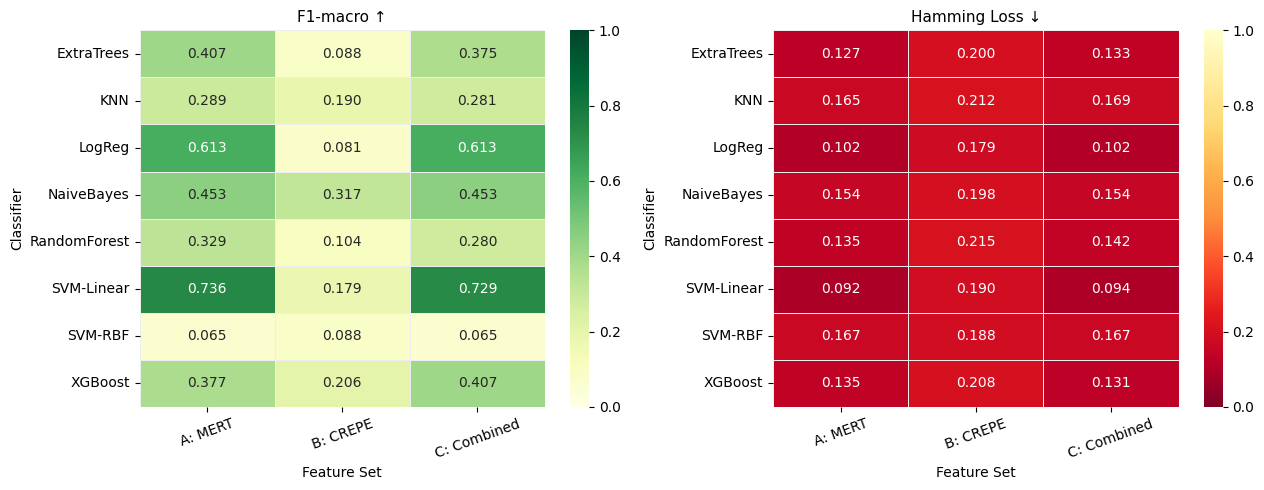

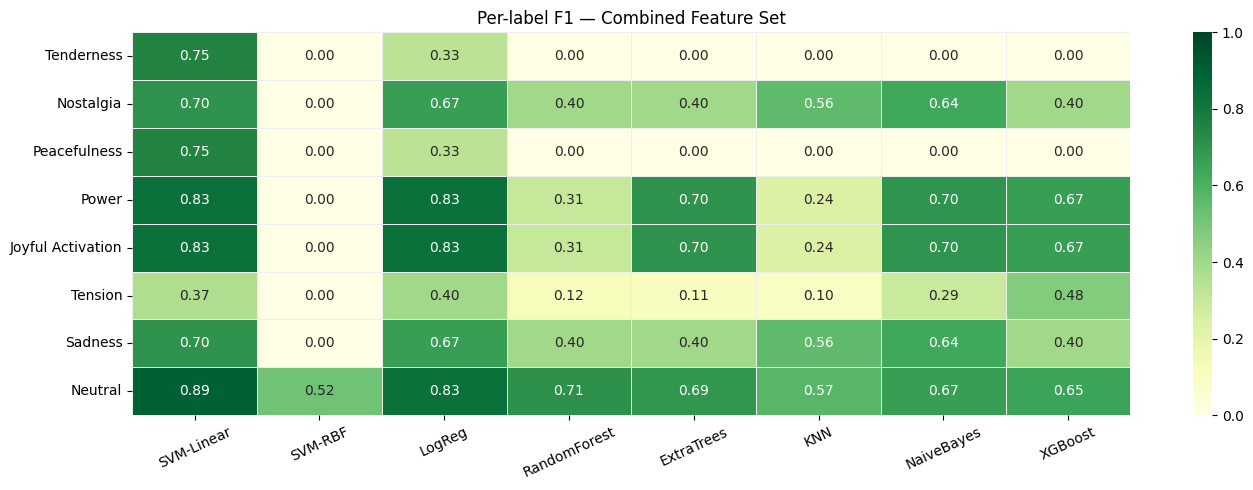

In [28]:
# ── Fig 2: Ablation heatmap ───────────────────────────────────────────────────
fig,axes=plt.subplots(1,2,figsize=(13,5))
for ax,(piv,title,cmap) in zip(axes,[(pivot_f1,'F1-macro ↑','YlGn'),(pivot_hl,'Hamming Loss ↓','YlOrRd_r')]):
    sns.heatmap(piv,ax=ax,annot=True,fmt='.3f',cmap=cmap,vmin=0,vmax=1,
                linewidths=0.4,linecolor='#eee')
    ax.set_title(title,fontsize=11); ax.tick_params(axis='x',rotation=20)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'fig_ablation_heatmap.png'),dpi=150,bbox_inches='tight'); plt.show()

# ── Fig 3: Per-label F1 heatmap ───────────────────────────────────────────────
pl_f1={n:f1_score(Y,r['Y_pred'],average=None,zero_division=0) for r in all_recs for n in [r['classifier']] if r['feature_set']=='C: Combined'}
df_pl=pd.DataFrame(pl_f1,index=mlb.classes_)
fig,ax=plt.subplots(figsize=(14,5))
sns.heatmap(df_pl,ax=ax,annot=True,fmt='.2f',cmap='YlGn',vmin=0,vmax=1,linewidths=0.4,linecolor='#eee')
ax.set_title('Per-label F1 — Combined Feature Set',fontsize=12); ax.tick_params(axis='x',rotation=25)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'fig_per_label_f1.png'),dpi=150,bbox_inches='tight'); plt.show()

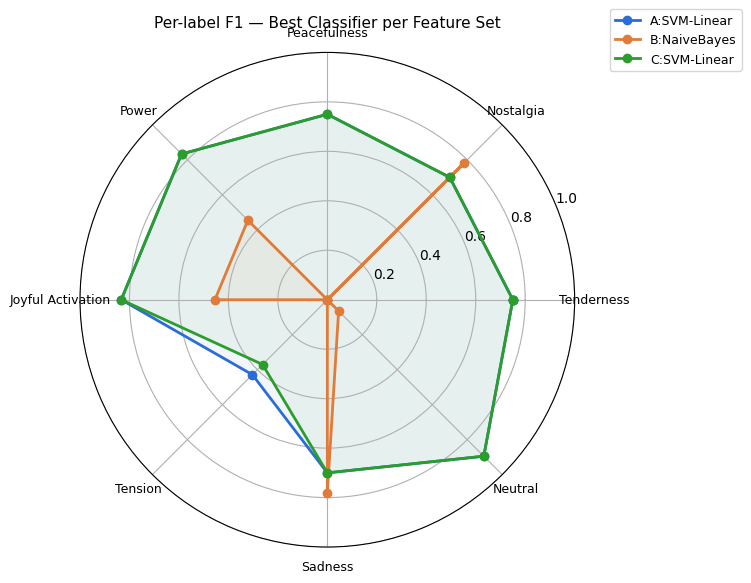

In [29]:
# ── Fig 4: Radar — per-label F1 by feature set (best clf each) ───────────────
def best_of(sname): return max((r for r in all_recs if r['feature_set']==sname),key=lambda r:r['f1_macro'])
bA,bB,bC=best_of('A: MERT'),best_of('B: CREPE'),best_of('C: Combined')
cats=list(mlb.classes_); N=len(cats); angles=[n/N*2*np.pi for n in range(N)]+[0]
fig,ax=plt.subplots(figsize=(8,8),subplot_kw={'polar':True})
for (nm,br),col in zip([(f'A:{bA["classifier"]}',bA),(f'B:{bB["classifier"]}',bB),
                         (f'C:{bC["classifier"]}',bC)],['#2a6dd9','#e07b39','#2a9d2a']):
    f1s=list(f1_score(Y,br['Y_pred'],average=None,zero_division=0))
    vals=f1s+[f1s[0]]
    ax.plot(angles,vals,'o-',lw=2,color=col,label=nm); ax.fill(angles,vals,alpha=0.06,color=col)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(cats,fontsize=9); ax.set_ylim(0,1)
ax.set_title('Per-label F1 — Best Classifier per Feature Set',fontsize=11,pad=18)
ax.legend(loc='upper right',bbox_to_anchor=(1.35,1.1),fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'fig_radar.png'),dpi=150,bbox_inches='tight'); plt.show()

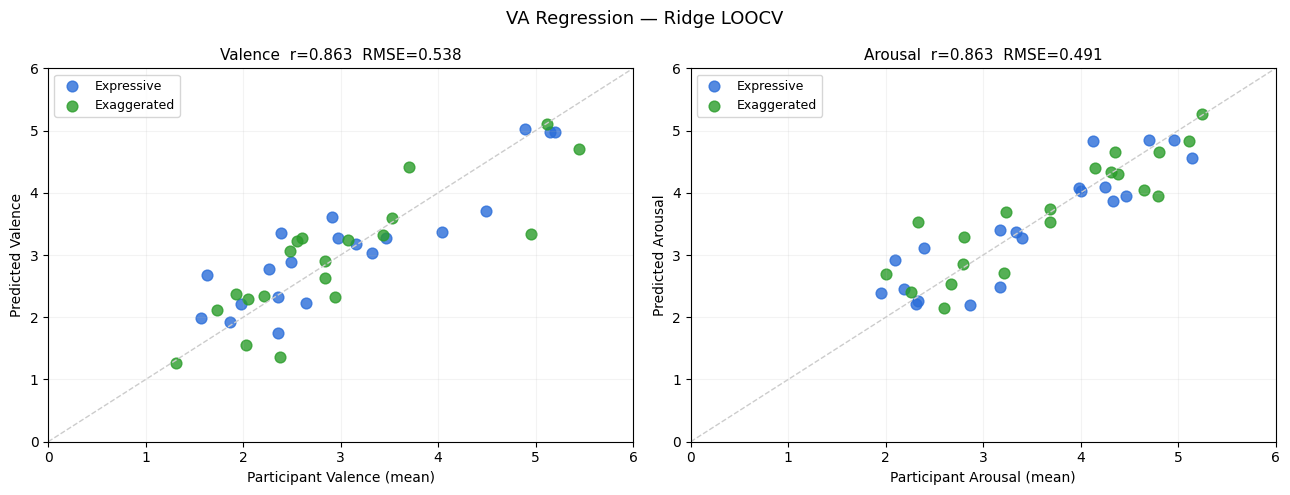

In [30]:
# ── Fig 5: VA scatter ─────────────────────────────────────────────────────────
cc={'EXP':'#2a6dd9','EXG':'#2a9d2a'}
fig,axes=plt.subplots(1,2,figsize=(13,5))
fig.suptitle('VA Regression — Ridge LOOCV',fontsize=13)
for ax,(tname,yt,yp) in zip(axes,[('Valence',y_valence,reg_res['Ridge']['vp']),
                                    ('Arousal',y_arousal,reg_res['Ridge']['ap'])]):
    for cond,col in cc.items():
        m=conditions==cond; ax.scatter(yt[m],yp[m],color=col,alpha=0.8,s=60,label=CONDITIONS[cond])
    ax.plot([0,6],[0,6],'--',color='#ccc',lw=1)
    r,_=pearsonr(yt,yp); rmse=np.sqrt(mean_squared_error(yt,yp))
    ax.set_title(f'{tname}  r={r:.3f}  RMSE={rmse:.3f}',fontsize=11)
    ax.set_xlabel(f'Participant {tname} (mean)'); ax.set_ylabel(f'Predicted {tname}')
    ax.set_xlim(0,6); ax.set_ylim(0,6); ax.legend(fontsize=9); ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'fig_va_scatter.png'),dpi=150,bbox_inches='tight'); plt.show()

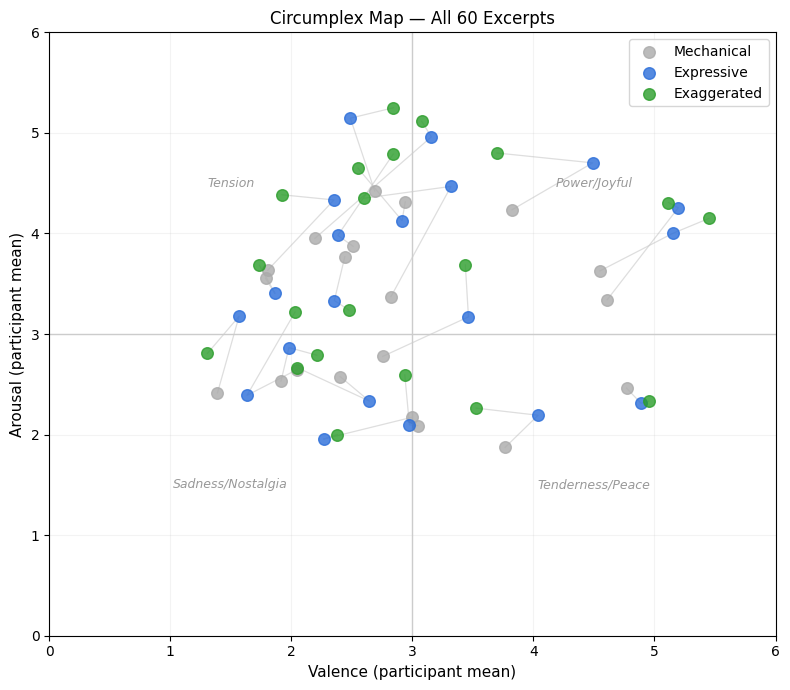

In [31]:
# ── Fig 6: Circumplex scatter ─────────────────────────────────────────────────
fig,ax=plt.subplots(figsize=(8,7))
cp={'MEC':'#aaa','EXP':'#2a6dd9','EXG':'#2a9d2a'}
# ── Connect the three interpretations (MEC→EXP→EXG) of each piece ─────────────
cond_order=['MEC','EXP','EXG']
for piece in df_all['piece'].unique():
    sub=df_all[df_all['piece']==piece].set_index('condition')
    if not all(c in sub.index for c in cond_order): continue
    xs=[sub.loc[c,'valence_mean'] for c in cond_order]
    ys=[sub.loc[c,'arousal_mean'] for c in cond_order]
    ax.plot(xs,ys,'-',color='#c8c8c8',lw=0.9,alpha=0.6,zorder=1)
for cond,col in cp.items():
    m=df_all['condition']==cond
    ax.scatter(df_all.loc[m,'valence_mean'],df_all.loc[m,'arousal_mean'],
               color=col,alpha=0.8,s=70,label=CONDITIONS[cond],zorder=3)
ax.axhline(VA_MID,color='#ccc',lw=1); ax.axvline(VA_MID,color='#ccc',lw=1)
for x,y,lbl in [(4.5,4.5,'Power/Joyful'),(1.5,4.5,'Tension'),
                   (4.5,1.5,'Tenderness/Peace'),(1.5,1.5,'Sadness/Nostalgia')]:
    ax.text(x,y,lbl,ha='center',va='center',fontsize=9,color='#999',style='italic')
ax.set_xlim(0,6); ax.set_ylim(0,6)
ax.set_xlabel('Valence (participant mean)',fontsize=11)
ax.set_ylabel('Arousal (participant mean)',fontsize=11)
ax.set_title('Circumplex Map — All 60 Excerpts',fontsize=12)
ax.legend(fontsize=10); ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'fig_circumplex.png'),dpi=150,bbox_inches='tight'); plt.show()

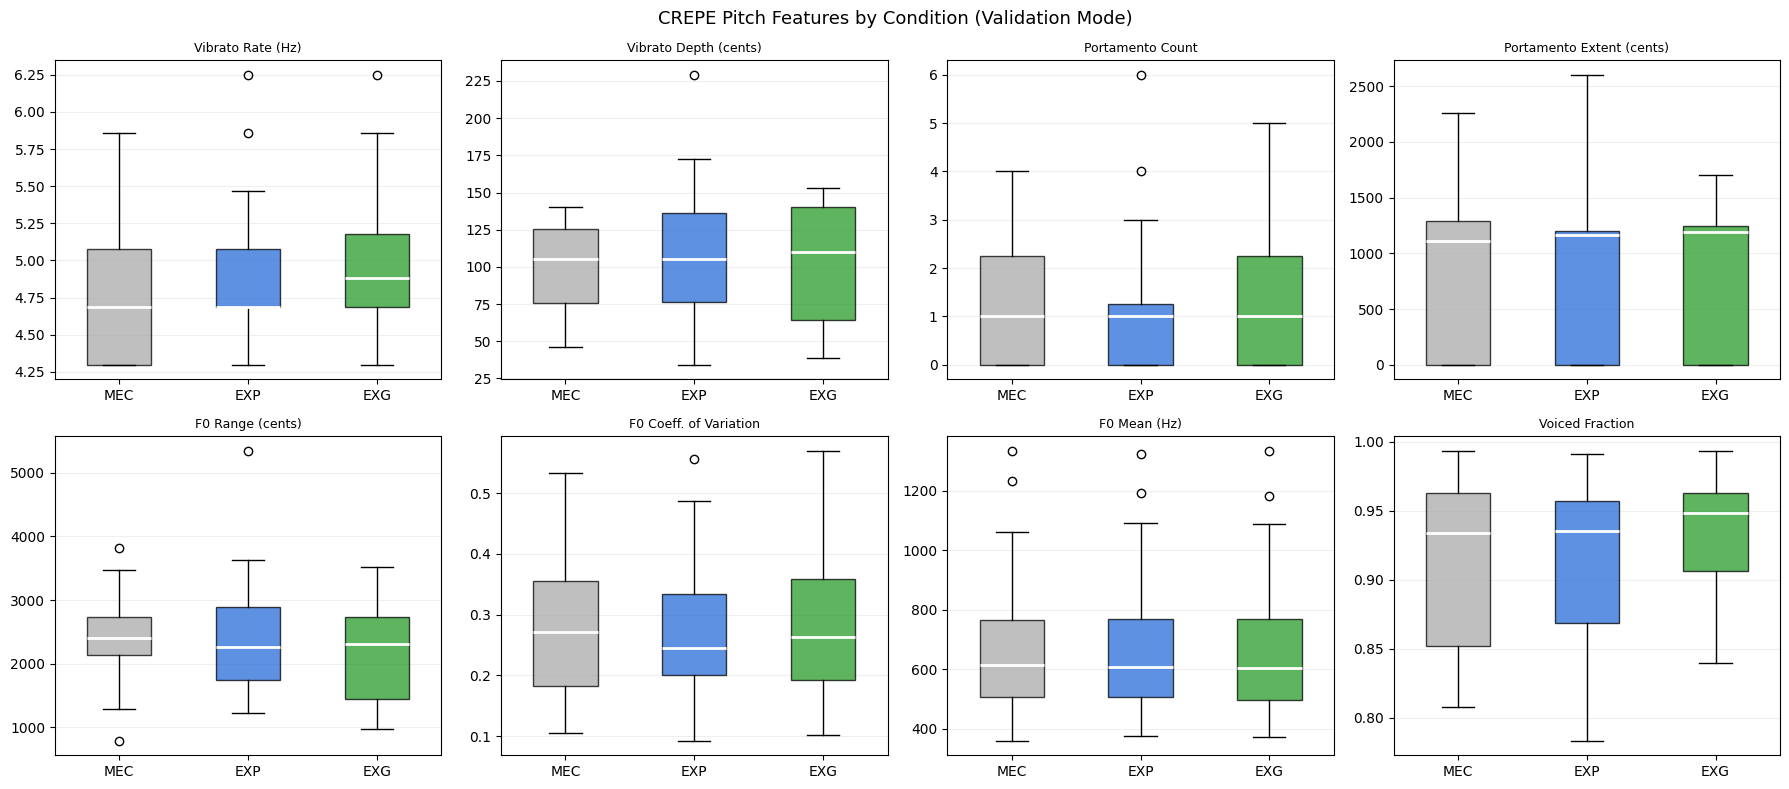

In [32]:
# ── Fig 7: Low-level features by condition ────────────────────────────────────
df_ll = df_crepe.copy()
df_ll['condition']=df_all.set_index('excerpt_id').reindex(df_ll.index)['condition']
feats_plot=[('crepe_vibrato_rate_hz',           'Vibrato Rate (Hz)'),
            ('crepe_vibrato_depth_cents',        'Vibrato Depth (cents)'),
            ('crepe_portamento_count',           'Portamento Count'),
            ('crepe_portamento_mean_ext_cents',  'Portamento Extent (cents)'),
            ('crepe_f0_range_cents',             'F0 Range (cents)'),
            ('crepe_f0_cv',                      'F0 Coeff. of Variation'),
            ('crepe_f0_mean_hz',                 'F0 Mean (Hz)'),
            ('crepe_voiced_fraction',            'Voiced Fraction')]
fig,axes=plt.subplots(2,4,figsize=(18,8))
fig.suptitle('CREPE Pitch Features by Condition (Validation Mode)',fontsize=13)
bpal={'MEC':'#aaa','EXP':'#2a6dd9','EXG':'#2a9d2a'}
for ax,(fc,fl) in zip(axes.flatten(),feats_plot):
    if fc not in df_ll.columns: ax.set_visible(False); continue
    data=[df_ll.loc[df_ll['condition']==c,fc].dropna().values for c in ['MEC','EXP','EXG']]
    bp=ax.boxplot(data,positions=[0,1,2],patch_artist=True,widths=0.5,
                  medianprops=dict(color='white',lw=2))
    for patch,col in zip(bp['boxes'],[bpal['MEC'],bpal['EXP'],bpal['EXG']]):
        patch.set_facecolor(col); patch.set_alpha(0.75)
    ax.set_xticks([0,1,2]); ax.set_xticklabels(['MEC','EXP','EXG'])
    ax.set_title(fl,fontsize=9); ax.grid(axis='y',alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'fig_lowlevel_conditions.png'),dpi=150,bbox_inches='tight'); plt.show()

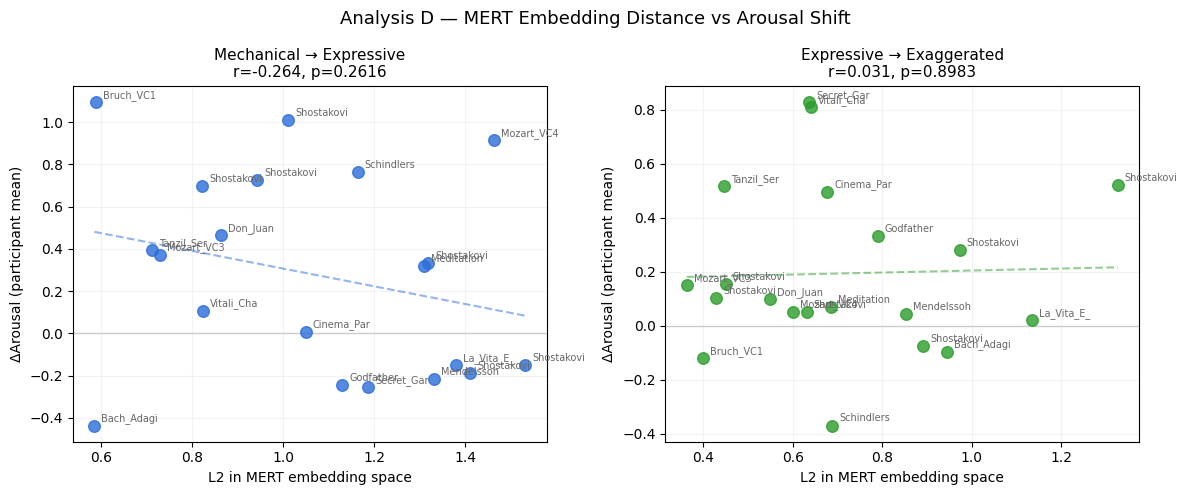

In [33]:
# ── Fig 8: Embedding distance vs ΔArousal ────────────────────────────────────
fig,axes=plt.subplots(1,2,figsize=(12,5))
fig.suptitle('Analysis D — MERT Embedding Distance vs Arousal Shift',fontsize=13)
for ax,(step,dc,dac,col) in zip(axes,[
    ('Mechanical → Expressive','dist_ME','daro_ME','#2a6dd9'),
    ('Expressive → Exaggerated','dist_EX','daro_EX','#2a9d2a')]):
    x,y=df_sh[dc].values,df_sh[dac].values
    ax.scatter(x,y,color=col,alpha=0.8,s=70,zorder=3)
    for _,row in df_sh.iterrows():
        ax.annotate(row['piece'][:10],(row[dc],row[dac]),
                    textcoords='offset points',xytext=(5,3),fontsize=7,color='#666')
    if len(x)>=3:
        m_,b_=np.polyfit(x,y,1)
        ax.plot(np.linspace(x.min(),x.max(),100),m_*np.linspace(x.min(),x.max(),100)+b_,
                '--',color=col,alpha=0.5,lw=1.5)
        r,p=pearsonr(x,y)
        ax.set_title(f'{step}\nr={r:.3f}, p={p:.4f}',fontsize=11)
    ax.axhline(0,color='#ccc',lw=1); ax.set_xlabel('L2 in MERT embedding space')
    ax.set_ylabel('ΔArousal (participant mean)'); ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'fig_embedding_shift.png'),dpi=150,bbox_inches='tight'); plt.show()

## Figures TE1–TE3: Technique–Emotion Association

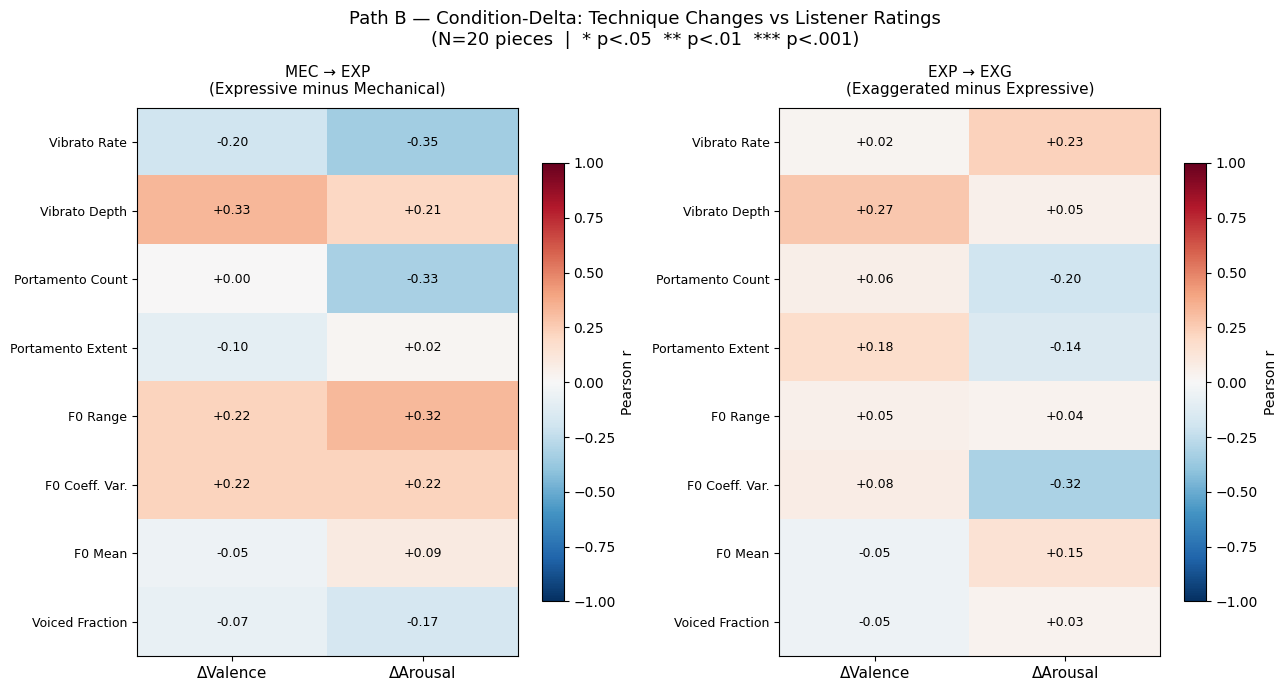

✅ Fig TE1 saved → /kaggle/working/pipeline_outputs/fig_delta_correlation.png


In [34]:
# ── Fig TE1: Condition-Delta Correlation Heatmap ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 7))
fig.suptitle(
    'Path B — Condition-Delta: Technique Changes vs Listener Ratings\n'
    f'(N={len(df_delta)} pieces  |  * p<.05  ** p<.01  *** p<.001)',
    fontsize=13
)
for ax, (r_mat, p_mat, title) in zip(axes, [
    (r_ME, p_ME, 'MEC → EXP\n(Expressive minus Mechanical)'),
    (r_EX, p_EX, 'EXP → EXG\n(Exaggerated minus Expressive)'),
]):
    im = ax.imshow(r_mat, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
    ax.set_xticks([0,1]); ax.set_xticklabels(['ΔValence','ΔArousal'], fontsize=11)
    ax.set_yticks(range(len(feat_short))); ax.set_yticklabels(feat_short, fontsize=9)
    ax.set_title(title, fontsize=11, pad=10)
    for i in range(r_mat.shape[0]):
        for jj in range(r_mat.shape[1]):
            p = p_mat[i,jj]; rv = r_mat[i,jj]
            s = '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else ''
            ax.text(jj, i, f'{rv:+.2f}{s}', ha='center', va='center', fontsize=9,
                    fontweight='bold' if s else 'normal',
                    color='white' if abs(rv)>0.6 else 'black')
    plt.colorbar(im, ax=ax, label='Pearson r', shrink=0.8)
plt.tight_layout()
fpath = os.path.join(OUTPUT_DIR,'fig_delta_correlation.png')
plt.savefig(fpath, dpi=150, bbox_inches='tight'); plt.show()
print(f'✅ Fig TE1 saved → {fpath}')

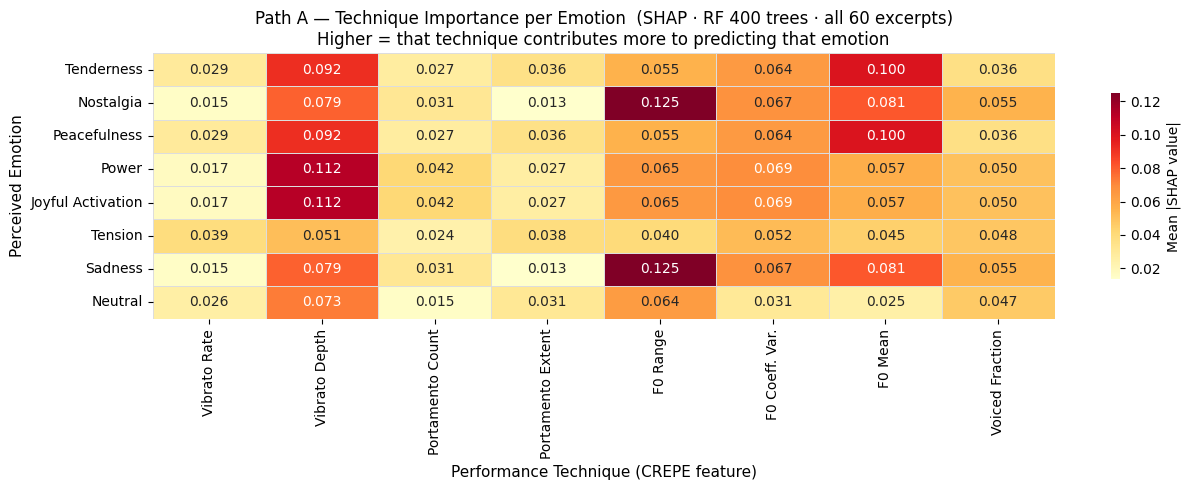

✅ Fig TE2 saved → /kaggle/working/pipeline_outputs/fig_shap_importance.png


In [35]:
# ── Fig TE2: SHAP Technique Importance Heatmap ───────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    df_shap_importance, annot=True, fmt='.3f', cmap='YlOrRd',
    linewidths=0.5, linecolor='#ddd', ax=ax,
    cbar_kws={'label':'Mean |SHAP value|', 'shrink':0.7}
)
ax.set_xlabel('Performance Technique (CREPE feature)', fontsize=11)
ax.set_ylabel('Perceived Emotion', fontsize=11)
ax.set_title(
    'Path A — Technique Importance per Emotion  (SHAP · RF 400 trees · all 60 excerpts)\n'
    'Higher = that technique contributes more to predicting that emotion',
    fontsize=12
)
plt.tight_layout()
fpath = os.path.join(OUTPUT_DIR,'fig_shap_importance.png')
plt.savefig(fpath, dpi=150, bbox_inches='tight'); plt.show()
print(f'✅ Fig TE2 saved → {fpath}')

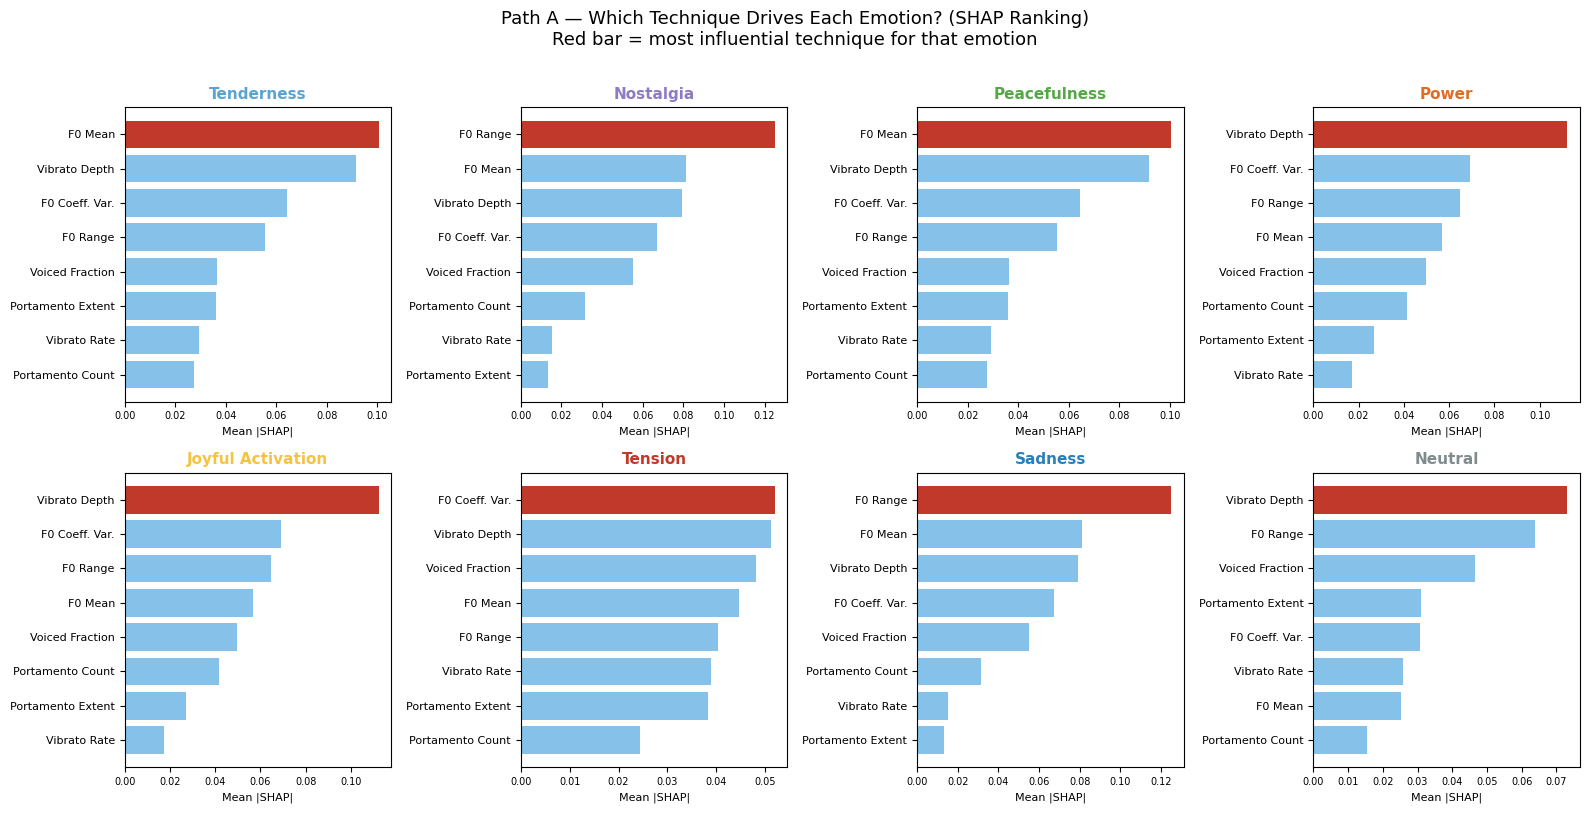

✅ Fig TE3 saved → /kaggle/working/pipeline_outputs/fig_shap_ranked.png

Beeswarm → Nostalgia


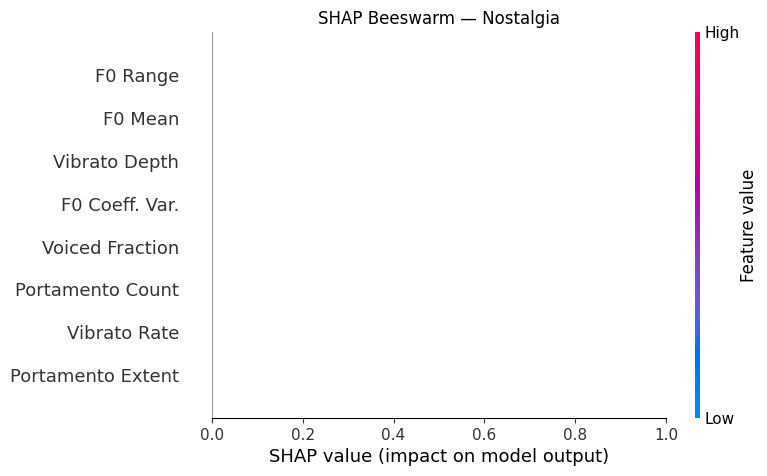

✅ Beeswarm saved → /kaggle/working/pipeline_outputs/fig_shap_beeswarm_Nostalgia.png


In [36]:
# ── Fig TE3: Ranked bar per emotion + beeswarm for top emotion ───────────────
COND_COLORS = {
    'Tenderness':'#5ba4cf','Nostalgia':'#8e7cc3','Peacefulness':'#57a64a',
    'Power':'#e06c26','Joyful Activation':'#f5c342','Tension':'#c0392b',
    'Sadness':'#2980b9','Neutral':'#7f8c8d'
}
emotions_active = [e for e in mlb.classes_ if e in shap_vals_all]
ncols = 4; nrows = (len(emotions_active) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = axes.flatten()
for idx, emotion in enumerate(emotions_active):
    ax    = axes[idx]
    vals  = df_shap_importance.loc[emotion].values
    order = np.argsort(vals)[::-1]
    colors = ['#c0392b' if i==order[0] else '#85c1e9' for i in range(len(vals))]
    ax.barh([feat_short[i] for i in order[::-1]], vals[order[::-1]],
            color=[colors[i] for i in order[::-1]])
    ax.set_title(emotion, fontsize=11,
                 color=COND_COLORS.get(emotion,'#333'), fontweight='bold')
    ax.set_xlabel('Mean |SHAP|', fontsize=8)
    ax.tick_params(axis='y', labelsize=8); ax.tick_params(axis='x', labelsize=7)
for idx in range(len(emotions_active), len(axes)):
    axes[idx].set_visible(False)
fig.suptitle(
    'Path A — Which Technique Drives Each Emotion? (SHAP Ranking)\n'
    'Red bar = most influential technique for that emotion',
    fontsize=13, y=1.01
)
plt.tight_layout()
fpath = os.path.join(OUTPUT_DIR,'fig_shap_ranked.png')
plt.savefig(fpath, dpi=150, bbox_inches='tight'); plt.show()
print(f'✅ Fig TE3 saved → {fpath}')

# ── Beeswarm for the emotion where SHAP is most decisive ──────────────────────
key_em = max(shap_vals_all, key=lambda e: df_shap_importance.loc[e].max())
print(f'\nBeeswarm → {key_em}')
shap.summary_plot(shap_vals_all[key_em], features=X_B_sc,
                  feature_names=feat_short, plot_type='beeswarm',
                  show=False, max_display=8)
plt.title(f'SHAP Beeswarm — {key_em}', fontsize=12)
fpath_bee = os.path.join(OUTPUT_DIR, f'fig_shap_beeswarm_{key_em.replace(" ","_")}.png')
plt.savefig(fpath_bee, dpi=150, bbox_inches='tight'); plt.show()
print(f'✅ Beeswarm saved → {fpath_bee}')

## 23. Save All Outputs + Reporting Checklist

In [37]:
# ── Final summary table ───────────────────────────────────────────────────────
rows=[]
for sn in ['A: MERT','B: CREPE','C: Combined']:
    sub=[r for r in all_recs if r['feature_set']==sn]
    br=max(sub,key=lambda r:r['f1_macro'])
    rows.append({'Feature Set':sn,'Best Classifier':br['classifier'],
                 'Best F1-macro':f"{br['f1_macro']:.4f}",
                 'Avg F1-macro':f"{np.mean([r['f1_macro'] for r in sub]):.4f}",
                 'Avg Hamming':f"{np.mean([r['hamming_loss'] for r in sub]):.4f}"})
rows.append({'Feature Set':'Baseline (MFCC+SVM)','Best Classifier':'SVM-RBF',
             'Best F1-macro':f'{bl_f1m:.4f}','Avg F1-macro':f'{bl_f1m:.4f}','Avg Hamming':f'{bl_hl:.4f}'})
df_final=pd.DataFrame(rows)
print('\n📊 FINAL SUMMARY'); print('='*70); print(df_final.to_string(index=False))
df_final.to_csv(os.path.join(OUTPUT_DIR,'final_summary.csv'),index=False)

# Save predictions
df_expr['best_pred_labels']=[list(mlb.classes_[np.where(r)[0]]) for r in best_r['Y_pred']]
df_expr['pred_valence']=reg_res['Ridge']['vp']
df_expr['pred_arousal']=reg_res['Ridge']['ap']
df_expr['pred_quadrant']=pred_quads
df_expr.to_csv(os.path.join(OUTPUT_DIR,'all_predictions.csv'),index=False)
df_sh.to_csv(os.path.join(OUTPUT_DIR,'analysis_d_shifts.csv'),index=False)
print(f'\n✅ All outputs in: {OUTPUT_DIR}')


📊 FINAL SUMMARY
        Feature Set Best Classifier Best F1-macro Avg F1-macro Avg Hamming
            A: MERT      SVM-Linear        0.7362       0.4086      0.1346
           B: CREPE      NaiveBayes        0.3174       0.1568      0.1987
        C: Combined      SVM-Linear        0.7290       0.4003      0.1365
Baseline (MFCC+SVM)         SVM-RBF        0.0000       0.0000      0.2021

✅ All outputs in: /kaggle/working/pipeline_outputs


---
## 📋 Output File Reference — Validation Mode (MERT + CREPE)
| File | Contents |
|---|---|
| `emb_mert.npz` | MERT 768-dim embeddings (all 60 excerpts, cached) |
| `feat_crepe.csv` | CREPE pitch/vibrato features (8-dim) |
| `ablation_results.csv` | 3-set × 8-classifier LOOCV results |
| `final_summary.csv` | Best/avg per feature set |
| `all_predictions.csv` | Per-excerpt GT + predictions |
| `analysis_d_shifts.csv` | Piece-level embedding distances + VA deltas |
| `fig_ablation_bar.png` | Grouped bar: MERT vs CREPE vs Combined |
| `fig_ablation_heatmap.png` | F1 / Hamming heatmaps |
| `fig_radar.png` | Per-label F1 radar (best clf per set) |
| `fig_quadrant_cm.png` | VA quadrant confusion matrix |
| `fig_va_scatter.png` | Valence / arousal regression scatter |
| `fig_circumplex.png` | VA circumplex — all 60 excerpts |
| `fig_lowlevel_conditions.png` | CREPE features by condition (MEC/EXP/EXG) |
| `fig_embedding_shift.png` | MERT distance vs ΔArousal |
